# 04 — Conditional DDPM Training

Treina um **Conditional Denoising Diffusion Probabilistic Model (DDPM)** para gerar imagens sintéticas de borboletas condicionadas à classe.

## Teoria resumida

Um DDPM tem dois processos:

- **Forward process (fixo):** adiciona ruído gaussiano a uma imagem real em T passos até obter ruído puro.  
  `xₜ = √ᾱₜ · x₀ + √(1-ᾱₜ) · ε`, onde `ε ~ N(0,I)` e `ᾱₜ = ∏(1-βᵢ)`.  
  Isto permite **amostrar xₜ diretamente** sem iterar os T passos.

- **Reverse process (treinável):** uma U-Net aprende a prever o ruído `ε` a partir de `(xₜ, t, classe)`.  
  A loss é simplesmente MSE: `L = ||ε - εθ(xₜ, t, y)||²`

Na inferência, parte-se de ruído puro e aplica-se a U-Net T vezes para reconstruir uma imagem limpa.  
Com **DDIM sampling** conseguimos fazer isso em apenas ~50 steps (muito mais rápido).

**Vantagem sobre o GAN:** sem instabilidade adversarial, sem mode collapse, sem balanceamento G/D.


## Setup e imports

In [5]:
!pip install kagglehub==1.0.0 diffusers accelerate tqdm

Defaulting to user installation because normal site-packages is not writeable
ERROR: Ignored the following yanked versions: 0.2.6
ERROR: Ignored the following versions that require a different python version: 0.4.0 Requires-Python >=3.10; 0.4.1 Requires-Python >=3.10; 0.4.2 Requires-Python >=3.10; 0.4.3 Requires-Python >=3.10; 1.0.0 Requires-Python >=3.10; 1.0.1 Requires-Python >=3.10
ERROR: Could not find a version that satisfies the requirement kagglehub==1.0.0 (from versions: 0.0.1a0, 0.0.1a1, 0.1.0, 0.1.1, 0.1.2, 0.1.3, 0.1.4, 0.1.5, 0.1.6, 0.1.7, 0.1.8, 0.1.9, 0.2.0, 0.2.1, 0.2.2, 0.2.3, 0.2.4, 0.2.5, 0.2.7, 0.2.8, 0.2.9, 0.3.0, 0.3.1, 0.3.2, 0.3.3, 0.3.4, 0.3.5, 0.3.6, 0.3.7, 0.3.8, 0.3.9, 0.3.10, 0.3.11, 0.3.12, 0.3.13)
ERROR: No matching distribution found for kagglehub==1.0.0


In [7]:
import os, sys, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image as PILImage

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.utils as vutils
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# ── Paths ────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path(os.path.abspath("__file__")).parent
SRC_DIR      = (NOTEBOOK_DIR / "../src").resolve()
CKPT_DIR     = (NOTEBOOK_DIR / "../outputs/checkpoints/diffusion").resolve()
SAMPLE_DIR   = (NOTEBOOK_DIR / "../outputs/figures/diffusion_samples").resolve()

sys.path.insert(0, str(SRC_DIR))

CKPT_DIR.mkdir(parents=True, exist_ok=True)
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

# ── Dataset via kagglehub ─────────────────────────────────────────────────────
import kagglehub
dataset_path = Path(kagglehub.competition_download("aca-tp-2"))

train_dir      = dataset_path / "train"
test_dir       = dataset_path / "test"
train_csv_path = dataset_path / "train.csv"

print(f"Dataset path : {dataset_path}")
print(f"Train images : {len(list(train_dir.iterdir()))} ficheiros")

from dataset import ButterflyDataset
from utils   import get_splits, GLOBAL_SEED

device = (
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Device       : {device}")
torch.manual_seed(GLOBAL_SEED)

Dataset path : /Users/ritapduarte/.cache/kagglehub/competitions/aca-tp-2
Train images : 5199 ficheiros
Device       : mps


## Hiperparâmetros

In [8]:
# ── Diffusion schedule ───────────────────────────────────────────────────────
T_STEPS        = 1000        # número de steps de difusão
BETA_START     = 1e-4        # β₁
BETA_END       = 0.02        # βᵀ

# ── Treino ───────────────────────────────────────────────────────────────────
NUM_EPOCHS     = 500         # epochs totais
BATCH_SIZE     = 16          # pequeno para poupar VRAM/RAM
LR             = 2e-4        # learning rate
GRAD_CLIP      = 1.0         # gradient clipping (estabilidade)

# ── Modelo ───────────────────────────────────────────────────────────────────
IMAGE_SIZE     = 64
NUM_CLASSES    = 75
CLASS_EMB_DIM  = 128         # dimensão do embedding de classe
BASE_CHANNELS  = 64          # canais base da U-Net (aumentar se tiveres VRAM)

# ── Checkpoints/visualização ─────────────────────────────────────────────────
SAVE_EVERY     = 10          # guardar checkpoint a cada N epochs
N_SAMPLE_IMGS  = 75          # 1 imagem por classe nas grelhas

# ── Inferência (DDIM) ────────────────────────────────────────────────────────
DDIM_STEPS     = 50          # steps de sampling (muito mais rápido que 1000)

print("Hiperparâmetros definidos.")

Hiperparâmetros definidos.


## Noise Schedule

O schedule define como o ruído aumenta ao longo dos T steps. Usamos um **linear schedule** (o original do paper DDPM).
Pré-calculamos `ᾱₜ = ∏(1-βᵢ)` para poder saltar diretamente para qualquer step t durante o treino.

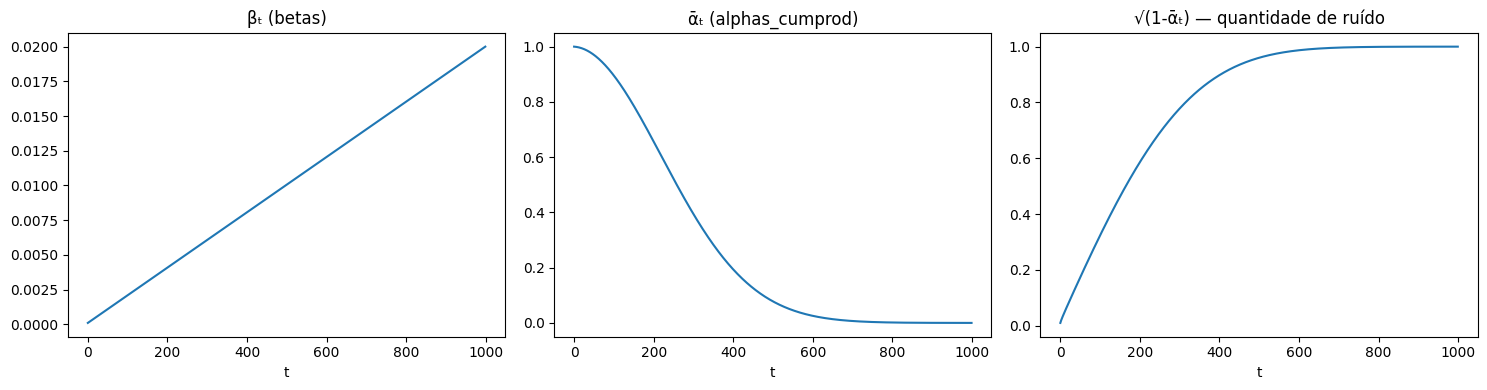

Schedule calculado.


In [19]:
def make_beta_schedule(timesteps, start=BETA_START, end=BETA_END):
    """Schedule linear: βₜ cresce linearmente de start a end."""
    return torch.linspace(start, end, timesteps)


class DiffusionSchedule:
    """
    Pré-calcula todas as quantidades derivadas do noise schedule.
    Mantido em CPU; move para device quando necessário.
    """
    def __init__(self, timesteps=T_STEPS, beta_start=BETA_START, beta_end=BETA_END):
        self.T = timesteps

        betas              = make_beta_schedule(timesteps, beta_start, beta_end)
        alphas             = 1.0 - betas
        alphas_cumprod     = torch.cumprod(alphas, dim=0)          # ᾱₜ
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

        self.register = lambda name, val: setattr(self, name, val)
        self.register("betas",               betas)
        self.register("alphas",              alphas)
        self.register("alphas_cumprod",      alphas_cumprod)
        self.register("alphas_cumprod_prev", alphas_cumprod_prev)
        self.register("sqrt_alphas_cumprod",      alphas_cumprod.sqrt())
        self.register("sqrt_one_minus_alphas_cumprod", (1 - alphas_cumprod).sqrt())
        # para denoising
        self.register("posterior_variance",
                      betas * (1 - alphas_cumprod_prev) / (1 - alphas_cumprod))

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        t_cpu = t.cpu()  # garante que t está em CPU
        sqrt_ac  = self.sqrt_alphas_cumprod[t_cpu].to(x0.device)
        sqrt_omc = self.sqrt_one_minus_alphas_cumprod[t_cpu].to(x0.device)
        sqrt_ac  = sqrt_ac.view(-1, 1, 1, 1)
        sqrt_omc = sqrt_omc.view(-1, 1, 1, 1)
        return sqrt_ac * x0 + sqrt_omc * noise, noise


schedule = DiffusionSchedule(T_STEPS, BETA_START, BETA_END)

# Visualização do schedule
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
t_range = np.arange(T_STEPS)
axes[0].plot(t_range, schedule.betas.numpy());          axes[0].set_title("βₜ (betas)")
axes[1].plot(t_range, schedule.alphas_cumprod.numpy()); axes[1].set_title("ᾱₜ (alphas_cumprod)")
axes[2].plot(t_range, schedule.sqrt_one_minus_alphas_cumprod.numpy())
axes[2].set_title("√(1-ᾱₜ) — quantidade de ruído")
for ax in axes: ax.set_xlabel("t")
plt.tight_layout()
plt.savefig(SAMPLE_DIR / "noise_schedule.png", dpi=150, bbox_inches="tight")
plt.show()
print("Schedule calculado.")

## Dataset e DataLoader

Usa a mesma transform do GAN: redimensionar para 64×64 e normalizar para [-1, 1] (compatível com a saída Tanh).

In [14]:
# Transform para o Diffusion: imagens em [-1, 1]
diff_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),   # [-1, 1]
])

train_csv = pd.read_csv(train_csv_path)
train_df, val_df = get_splits(train_csv, seed=GLOBAL_SEED)

# Mapeamento de classes (consistência com class_to_idx.json)
with open("class_to_idx.json") as f:
    class_to_idx = json.load(f)
idx_to_class = {v: k for k, v in class_to_idx.items()}

train_df = train_df.copy()
train_df["label_idx"] = train_df["label"].map(class_to_idx)

train_dataset = ButterflyDataset(
    train_df,
    img_dir=str(train_dir),
    transform=diff_transform,
)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=(device == "cuda"),
    drop_last=True,
)

print(f"Treino  : {len(train_dataset)} imagens | {len(train_loader)} batches por epoch")
print(f"Classes : {NUM_CLASSES}")

Treino  : 4159 imagens | 259 batches por epoch
Classes : 75


## Arquitetura: Conditional U-Net

A U-Net é o modelo padrão para DDPMs. Recebe `(xₜ, t, classe)` e prevê o ruído `ε`.  
O condicionamento acontece injectando:
- **Time embedding** (sinusoidal + MLP) nos blocos residuais
- **Class embedding** somado ao time embedding

A arquitetura é um encoder-decoder com skip connections, típica de segmentação.

In [9]:
import math

# ── Time Embedding (sinusoidal, como no paper original) ──────────────────────
class SinusoidalPosEmb(nn.Module):
    """Embedding posicional sinusoidal para o timestep t."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device    = t.device
        half_dim  = self.dim // 2
        emb_scale = math.log(10000) / (half_dim - 1)
        emb       = torch.exp(torch.arange(half_dim, device=device) * -emb_scale)
        emb       = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)


# ── Bloco Residual condicionado em tempo e classe ────────────────────────────
class ResBlock(nn.Module):
    """
    Bloco residual da U-Net.
    Injeta o time+class embedding via projeção linear adicionada aos feature maps.
    """
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.norm1   = nn.GroupNorm(8, in_ch)
        self.conv1   = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2   = nn.GroupNorm(8, out_ch)
        self.conv2   = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_ch * 2)   # scale + shift
        )
        # skip connection se canais mudarem
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, time_emb):
        h     = self.conv1(F.silu(self.norm1(x)))
        # time/class conditioning: scale & shift
        t_out = self.time_mlp(time_emb)           # (B, out_ch*2)
        scale, shift = t_out.chunk(2, dim=1)
        h     = h * (scale[:, :, None, None] + 1) + shift[:, :, None, None]
        h     = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


# ── Conditional U-Net ────────────────────────────────────────────────────────
class ConditionalUNet(nn.Module):
    """
    U-Net condicional para DDPM.
    Entrada: (xₜ: B×3×64×64, t: B, y: B)
    Saída  : ε_pred: B×3×64×64 (ruído previsto)
    """
    def __init__(self, image_channels=3, base_channels=BASE_CHANNELS,
                 num_classes=NUM_CLASSES, class_emb_dim=CLASS_EMB_DIM):
        super().__init__()
        c  = base_channels
        tc = c * 4   # dimensão interna do time embedding

        # ── Time embedding ────────────────────────────────────────────────
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(c),
            nn.Linear(c, tc),
            nn.SiLU(),
            nn.Linear(tc, tc),
        )

        # ── Class embedding ───────────────────────────────────────────────
        self.class_emb = nn.Embedding(num_classes, class_emb_dim)
        self.class_mlp = nn.Sequential(
            nn.Linear(class_emb_dim, tc),
            nn.SiLU(),
        )

        # ── Encoder (downsample) ──────────────────────────────────────────
        self.init_conv   = nn.Conv2d(image_channels, c, 3, padding=1)

        self.enc1 = ResBlock(c,     c*2,  tc)     # 64×64 → 64×64
        self.down1 = nn.Conv2d(c*2, c*2, 4, stride=2, padding=1)  # → 32×32

        self.enc2 = ResBlock(c*2,   c*4,  tc)     # 32×32
        self.down2 = nn.Conv2d(c*4, c*4, 4, stride=2, padding=1)  # → 16×16

        self.enc3 = ResBlock(c*4,   c*8,  tc)     # 16×16
        self.down3 = nn.Conv2d(c*8, c*8, 4, stride=2, padding=1)  # → 8×8

        # ── Bottleneck ────────────────────────────────────────────────────
        self.mid1 = ResBlock(c*8,   c*8,  tc)
        self.mid2 = ResBlock(c*8,   c*8,  tc)

        # ── Decoder (upsample) ────────────────────────────────────────────
        self.up3   = nn.ConvTranspose2d(c*8,  c*8, 4, stride=2, padding=1)  # → 16×16
        self.dec3  = ResBlock(c*8 + c*8, c*4, tc)  # skip connection do enc3

        self.up2   = nn.ConvTranspose2d(c*4,  c*4, 4, stride=2, padding=1)  # → 32×32
        self.dec2  = ResBlock(c*4 + c*4, c*2, tc)  # skip connection do enc2

        self.up1   = nn.ConvTranspose2d(c*2,  c*2, 4, stride=2, padding=1)  # → 64×64
        self.dec1  = ResBlock(c*2 + c*2, c,   tc)  # skip connection do enc1

        # ── Cabeça final ──────────────────────────────────────────────────
        self.final_norm = nn.GroupNorm(8, c)
        self.final_conv = nn.Conv2d(c, image_channels, 1)

    def forward(self, x, t, y):
        """
        x : (B, 3, 64, 64) — imagem com ruído
        t : (B,)            — timestep
        y : (B,)            — índice da classe
        """
        # Time + class embedding combinados
        t_emb = self.time_mlp(t)                         # (B, tc)
        c_emb = self.class_mlp(self.class_emb(y))        # (B, tc)
        emb   = t_emb + c_emb                            # (B, tc)

        # Encoder
        x0 = self.init_conv(x)                           # (B, c, 64, 64)
        e1 = self.enc1(x0, emb)                          # (B, c*2, 64, 64)
        e2 = self.enc2(self.down1(e1), emb)              # (B, c*4, 32, 32)
        e3 = self.enc3(self.down2(e2), emb)              # (B, c*8, 16, 16)

        # Bottleneck
        m  = self.mid2(self.mid1(self.down3(e3), emb), emb)  # (B, c*8, 8×8)

        # Decoder com skip connections
        d3 = self.dec3(torch.cat([self.up3(m),  e3], dim=1), emb)  # (B, c*4, 16×16)
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1), emb)  # (B, c*2, 32×32)
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1), emb)  # (B, c,   64×64)

        return self.final_conv(F.silu(self.final_norm(d1)))


# Instanciar e mostrar
model = ConditionalUNet(
    image_channels=3,
    base_channels=BASE_CHANNELS,
    num_classes=NUM_CLASSES,
    class_emb_dim=CLASS_EMB_DIM,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"U-Net — Parâmetros treináveis: {n_params:,}")
print(model)

U-Net — Parâmetros treináveis: 30,842,371
ConditionalUNet(
  (time_mlp): Sequential(
    (0): SinusoidalPosEmb()
    (1): Linear(in_features=64, out_features=256, bias=True)
    (2): SiLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
  )
  (class_emb): Embedding(75, 128)
  (class_mlp): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): SiLU()
  )
  (init_conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc1): ResBlock(
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 128, eps=1e-05, affine=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (time_mlp): Sequential(
      (0): SiLU()
      (1): Linear(in_features=256, out_features=256, bias=True)
    )
    (skip): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
  )
  (down1): Conv2d(128, 128, kernel_size=(4, 4), 

## Otimizador

In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()   # loss DDPM padrão: MSE entre ruído real e previsto

# Ruído e labels fixos para visualização consistente
fixed_noise  = torch.randn(N_SAMPLE_IMGS, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
fixed_labels = torch.arange(NUM_CLASSES, device=device, dtype=torch.long)

print("Otimizador e loss definidos.")

Otimizador e loss definidos.


## Funções Auxiliares

In [16]:
def save_checkpoint(epoch, model, optimizer, losses, filename):
    """Guarda estado completo para retomar treino."""
    torch.save({
        "epoch":            epoch,
        "model_state_dict": model.state_dict(),
        "opt_state_dict":   optimizer.state_dict(),
        "losses":           losses,
    }, filename)


def load_checkpoint(filename, model, optimizer):
    """Carrega checkpoint e retorna epoch de início e histórico de losses."""
    ckpt = torch.load(filename, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["opt_state_dict"])
    print(f"Checkpoint carregado: epoch {ckpt['epoch']}")
    return ckpt["epoch"] + 1, ckpt["losses"]


@torch.no_grad()
def ddim_sample(model, schedule, n_imgs, labels, ddim_steps=DDIM_STEPS, eta=0.0):
    """
    Gera imagens via DDIM sampling — muito mais rápido que DDPM padrão.
    eta=0.0 → determinístico; eta=1.0 → equivalente a DDPM.
    """
    model.eval()
    img = torch.randn(n_imgs, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)

    # Subsample uniformly os timesteps
    step_seq = list(reversed(range(0, schedule.T, schedule.T // ddim_steps)))

    for i, t_cur in enumerate(step_seq):
        t_prev = step_seq[i + 1] if i + 1 < len(step_seq) else -1

        t_batch = torch.full((n_imgs,), t_cur, device=device, dtype=torch.long)

        # Prever ruído
        eps = model(img, t_batch, labels)

        ac     = schedule.alphas_cumprod[t_cur]
        ac_prev = schedule.alphas_cumprod[t_prev] if t_prev >= 0 else torch.tensor(1.0)

        # Estimar x0
        x0_pred = (img - (1 - ac).sqrt() * eps) / ac.sqrt()
        x0_pred = x0_pred.clamp(-1, 1)

        # DDIM update
        sigma = eta * ((1 - ac_prev) / (1 - ac) * (1 - ac / ac_prev)).sqrt()
        noise = torch.randn_like(img) if eta > 0 else 0
        img   = ac_prev.sqrt() * x0_pred + (1 - ac_prev - sigma**2).clamp(min=0).sqrt() * eps + sigma * noise

    model.train()
    return img.clamp(-1, 1)


def save_sample_grid(model, schedule, fixed_noise, fixed_labels, epoch, save_dir, nrow=15):
    """Gera e guarda grelha de imagens sintéticas."""
    imgs = ddim_sample(model, schedule, len(fixed_labels), fixed_labels)
    imgs = (imgs * 0.5 + 0.5).clamp(0, 1)   # [-1,1] → [0,1]
    grid = vutils.make_grid(imgs, nrow=nrow, padding=2, normalize=False)
    vutils.save_image(grid, save_dir / f"samples_epoch_{epoch:04d}.png")
    return grid


print("Funções auxiliares definidas.")

Funções auxiliares definidas.


## Loop de Treino — Bloco 1 (epochs 1 → 50)

### Algoritmo DDPM por batch:
1. Amostrar timestep `t ~ Uniform(0, T)` para cada imagem do batch  
2. Amostrar ruído `ε ~ N(0, I)`  
3. Calcular `xₜ = √ᾱₜ·x₀ + √(1-ᾱₜ)·ε`  
4. Prever `ε_pred = U-Net(xₜ, t, classe)`  
5. Loss = `MSE(ε, ε_pred)` → backward → step

**Executa esta célula, espera terminar, fecha o notebook se precisares, e continua no Bloco 2.**

In [9]:
BLOCK_START = 0      # ← epoch de início deste bloco
BLOCK_END   = 50     # ← epoch de fim deste bloco
RESUME      = True   # ← True para retomar do último checkpoint; False para começar do zero

# ── Retomar checkpoint se existir e RESUME=True ──────────────────────────────
latest_ckpt = sorted(CKPT_DIR.glob("ckpt_epoch_*.pt"))
history = {"loss": []}
start_epoch = BLOCK_START

if latest_ckpt and RESUME:
    start_epoch, history = load_checkpoint(latest_ckpt[-1], model, optimizer)
    print(f"A retomar do epoch {start_epoch}")
else:
    print(f"A começar do epoch {start_epoch}")

# ── Treino ───────────────────────────────────────────────────────────────────
print(f"Início do treino: epochs {start_epoch+1} → {BLOCK_END}")

for epoch in range(start_epoch, BLOCK_END):
    model.train()
    epoch_loss = 0.0
    t0 = time.time()

    for real_imgs, labels in train_loader:
        real_imgs = real_imgs.to(device)
        labels    = labels.to(device)
        B         = real_imgs.size(0)

        # Passo 1-2: amostrar t e ruído
        t_rand = torch.randint(0, T_STEPS, (B,), device=device, dtype=torch.long)
        noise  = torch.randn_like(real_imgs)

        # Passo 3: forward process — adicionar ruído
        noisy_imgs, _ = schedule.q_sample(real_imgs, t_rand, noise)

        # Passo 4: prever ruído
        noise_pred = model(noisy_imgs, t_rand, labels)

        # Passo 5: loss + backward
        loss = criterion(noise_pred, noise)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    history["loss"].append(avg_loss)
    elapsed = time.time() - t0

    print(f"Epoch [{epoch+1:03d}/{BLOCK_END}]  loss={avg_loss:.4f}  [{elapsed:.1f}s]")

    # ── Guardar amostras visuais ──────────────────────────────────────────────
    if (epoch + 1) % SAVE_EVERY == 0 or epoch == 0:
        save_sample_grid(model, schedule, fixed_noise, fixed_labels, epoch + 1, SAMPLE_DIR)

    # ── Checkpoint periódico ──────────────────────────────────────────────────
    if (epoch + 1) % SAVE_EVERY == 0:
        ckpt_path = CKPT_DIR / f"ckpt_epoch_{epoch+1:04d}.pt"
        save_checkpoint(epoch, model, optimizer, history, ckpt_path)
        print(f"  ✔ Checkpoint guardado: {ckpt_path.name}")

print(f"\n Bloco 1 concluído (epochs 1 → {BLOCK_END}).")

A começar do epoch 0
Início do treino: epochs 1 → 50
Epoch [001/50]  loss=0.0949  [129.1s]
Epoch [002/50]  loss=0.0444  [129.2s]
Epoch [003/50]  loss=0.0424  [128.0s]
Epoch [004/50]  loss=0.0401  [127.8s]
Epoch [005/50]  loss=0.0365  [127.9s]
Epoch [006/50]  loss=0.0355  [127.4s]
Epoch [007/50]  loss=0.0354  [127.4s]
Epoch [008/50]  loss=0.0356  [127.7s]
Epoch [009/50]  loss=0.0326  [127.5s]
Epoch [010/50]  loss=0.0342  [127.5s]
  ✔ Checkpoint guardado: ckpt_epoch_0010.pt
Epoch [011/50]  loss=0.0323  [127.6s]
Epoch [012/50]  loss=0.0329  [127.3s]
Epoch [013/50]  loss=0.0316  [127.3s]
Epoch [014/50]  loss=0.0342  [129.2s]
Epoch [015/50]  loss=0.0325  [128.2s]
Epoch [016/50]  loss=0.0291  [129.1s]
Epoch [017/50]  loss=0.0315  [128.3s]
Epoch [018/50]  loss=0.0309  [128.0s]
Epoch [019/50]  loss=0.0309  [127.8s]
Epoch [020/50]  loss=0.0290  [127.8s]
  ✔ Checkpoint guardado: ckpt_epoch_0020.pt
Epoch [021/50]  loss=0.0301  [127.8s]
Epoch [022/50]  loss=0.0301  [127.6s]
Epoch [023/50]  loss=0.

## Loop de Treino — Bloco 2 (epochs 51 → 100)

Carrega automaticamente o checkpoint do Bloco 1 e continua.  
Podes fechar e reabrir o notebook entre blocos — o estado é totalmente guardado no checkpoint.

> **Nota:** certifica-te de que **o Setup e os imports** foram corridos antes de executar qualquer bloco.

In [10]:
BLOCK_START = 50
BLOCK_END   = 100
RESUME      = True

latest_ckpt = sorted(CKPT_DIR.glob("ckpt_epoch_*.pt"))
history = {"loss": []}
start_epoch = BLOCK_START

if latest_ckpt and RESUME:
    start_epoch, history = load_checkpoint(latest_ckpt[-1], model, optimizer)

print(f"Início do treino: epochs {start_epoch+1} → {BLOCK_END}")

for epoch in range(start_epoch, BLOCK_END):
    model.train()
    epoch_loss = 0.0
    t0 = time.time()

    for real_imgs, labels in train_loader:
        real_imgs = real_imgs.to(device)
        labels    = labels.to(device)
        B         = real_imgs.size(0)

        t_rand = torch.randint(0, T_STEPS, (B,), device=device, dtype=torch.long)
        noise  = torch.randn_like(real_imgs)
        noisy_imgs, _ = schedule.q_sample(real_imgs, t_rand, noise)
        noise_pred = model(noisy_imgs, t_rand, labels)
        loss = criterion(noise_pred, noise)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    history["loss"].append(avg_loss)
    elapsed = time.time() - t0
    print(f"Epoch [{epoch+1:03d}/{BLOCK_END}]  loss={avg_loss:.4f}  [{elapsed:.1f}s]")

    if (epoch + 1) % SAVE_EVERY == 0 or epoch == BLOCK_START:
        save_sample_grid(model, schedule, fixed_noise, fixed_labels, epoch + 1, SAMPLE_DIR)

    if (epoch + 1) % SAVE_EVERY == 0:
        ckpt_path = CKPT_DIR / f"ckpt_epoch_{epoch+1:04d}.pt"
        save_checkpoint(epoch, model, optimizer, history, ckpt_path)
        print(f"  ✔ Checkpoint guardado: {ckpt_path.name}")

print(f"\n Bloco 2 concluído (epochs 51 → {BLOCK_END}).")

Checkpoint carregado: epoch 49
Início do treino: epochs 51 → 100
Epoch [051/100]  loss=0.0285  [134.3s]
Epoch [052/100]  loss=0.0288  [134.0s]
Epoch [053/100]  loss=0.0292  [134.0s]
Epoch [054/100]  loss=0.0280  [134.2s]
Epoch [055/100]  loss=0.0279  [133.9s]
Epoch [056/100]  loss=0.0291  [134.0s]
Epoch [057/100]  loss=0.0271  [134.1s]
Epoch [058/100]  loss=0.0283  [134.6s]
Epoch [059/100]  loss=0.0297  [136.2s]
Epoch [060/100]  loss=0.0306  [134.5s]
  ✔ Checkpoint guardado: ckpt_epoch_0060.pt
Epoch [061/100]  loss=0.0282  [134.1s]
Epoch [062/100]  loss=0.0278  [135.8s]
Epoch [063/100]  loss=0.0274  [134.0s]
Epoch [064/100]  loss=0.0284  [133.9s]
Epoch [065/100]  loss=0.0280  [133.9s]
Epoch [066/100]  loss=0.0279  [134.0s]
Epoch [067/100]  loss=0.0278  [134.0s]
Epoch [068/100]  loss=0.0294  [134.0s]
Epoch [069/100]  loss=0.0267  [134.0s]
Epoch [070/100]  loss=0.0286  [134.1s]
  ✔ Checkpoint guardado: ckpt_epoch_0070.pt
Epoch [071/100]  loss=0.0276  [134.7s]
Epoch [072/100]  loss=0.0295

## Loop de Treino — Bloco 3 (epochs 101 → 150)

In [11]:
BLOCK_START = 100
BLOCK_END   = 150
RESUME      = True

latest_ckpt = sorted(CKPT_DIR.glob("ckpt_epoch_*.pt"))
history = {"loss": []}
start_epoch = BLOCK_START
if latest_ckpt and RESUME:
    start_epoch, history = load_checkpoint(latest_ckpt[-1], model, optimizer)

print(f"Início do treino: epochs {start_epoch+1} → {BLOCK_END}")

for epoch in range(start_epoch, BLOCK_END):
    model.train()
    epoch_loss = 0.0
    t0 = time.time()
    for real_imgs, labels in train_loader:
        real_imgs = real_imgs.to(device); labels = labels.to(device); B = real_imgs.size(0)
        t_rand = torch.randint(0, T_STEPS, (B,), device=device, dtype=torch.long)
        noise  = torch.randn_like(real_imgs)
        noisy_imgs, _ = schedule.q_sample(real_imgs, t_rand, noise)
        noise_pred = model(noisy_imgs, t_rand, labels)
        loss = criterion(noise_pred, noise)
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    history["loss"].append(avg_loss)
    print(f"Epoch [{epoch+1:03d}/{BLOCK_END}]  loss={avg_loss:.4f}  [{time.time()-t0:.1f}s]")
    if (epoch + 1) % SAVE_EVERY == 0 or epoch == BLOCK_START:
        save_sample_grid(model, schedule, fixed_noise, fixed_labels, epoch + 1, SAMPLE_DIR)
    if (epoch + 1) % SAVE_EVERY == 0:
        ckpt_path = CKPT_DIR / f"ckpt_epoch_{epoch+1:04d}.pt"
        save_checkpoint(epoch, model, optimizer, history, ckpt_path)
        print(f"  ✔ Checkpoint guardado: {ckpt_path.name}")
print(f"\n Bloco 3 concluído (epochs 101 → {BLOCK_END}).")

Checkpoint carregado: epoch 99
Início do treino: epochs 101 → 150
Epoch [101/150]  loss=0.0251  [135.9s]
Epoch [102/150]  loss=0.0261  [135.5s]
Epoch [103/150]  loss=0.0267  [135.6s]
Epoch [104/150]  loss=0.0274  [135.6s]
Epoch [105/150]  loss=0.0264  [135.5s]
Epoch [106/150]  loss=0.0273  [135.5s]
Epoch [107/150]  loss=0.0278  [135.7s]
Epoch [108/150]  loss=0.0283  [135.7s]
Epoch [109/150]  loss=0.0268  [135.7s]
Epoch [110/150]  loss=0.0276  [135.8s]
  ✔ Checkpoint guardado: ckpt_epoch_0110.pt
Epoch [111/150]  loss=0.0272  [135.8s]
Epoch [112/150]  loss=0.0284  [135.6s]
Epoch [113/150]  loss=0.0272  [135.8s]
Epoch [114/150]  loss=0.0256  [135.7s]
Epoch [115/150]  loss=0.0272  [135.6s]
Epoch [116/150]  loss=0.0251  [135.7s]
Epoch [117/150]  loss=0.0280  [135.8s]
Epoch [118/150]  loss=0.0278  [135.8s]
Epoch [119/150]  loss=0.0261  [135.7s]
Epoch [120/150]  loss=0.0255  [135.8s]
  ✔ Checkpoint guardado: ckpt_epoch_0120.pt
Epoch [121/150]  loss=0.0283  [135.8s]
Epoch [122/150]  loss=0.026

## Loop de Treino — Bloco 4 (epochs 151 → 200)

In [12]:
BLOCK_START = 150
BLOCK_END   = 200
RESUME      = True

latest_ckpt = sorted(CKPT_DIR.glob("ckpt_epoch_*.pt"))
history = {"loss": []}
start_epoch = BLOCK_START
if latest_ckpt and RESUME:
    start_epoch, history = load_checkpoint(latest_ckpt[-1], model, optimizer)

print(f"Início do treino: epochs {start_epoch+1} → {BLOCK_END}")

for epoch in range(start_epoch, BLOCK_END):
    model.train()
    epoch_loss = 0.0
    t0 = time.time()
    for real_imgs, labels in train_loader:
        real_imgs = real_imgs.to(device); labels = labels.to(device); B = real_imgs.size(0)
        t_rand = torch.randint(0, T_STEPS, (B,), device=device, dtype=torch.long)
        noise  = torch.randn_like(real_imgs)
        noisy_imgs, _ = schedule.q_sample(real_imgs, t_rand, noise)
        noise_pred = model(noisy_imgs, t_rand, labels)
        loss = criterion(noise_pred, noise)
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    history["loss"].append(avg_loss)
    print(f"Epoch [{epoch+1:03d}/{BLOCK_END}]  loss={avg_loss:.4f}  [{time.time()-t0:.1f}s]")
    if (epoch + 1) % SAVE_EVERY == 0 or epoch == BLOCK_START:
        save_sample_grid(model, schedule, fixed_noise, fixed_labels, epoch + 1, SAMPLE_DIR)
    if (epoch + 1) % SAVE_EVERY == 0:
        ckpt_path = CKPT_DIR / f"ckpt_epoch_{epoch+1:04d}.pt"
        save_checkpoint(epoch, model, optimizer, history, ckpt_path)
        print(f"  ✔ Checkpoint guardado: {ckpt_path.name}")
print(f"\n Bloco 4 concluído (epochs 151 → {BLOCK_END}).")

Checkpoint carregado: epoch 149
Início do treino: epochs 151 → 200
Epoch [151/200]  loss=0.0291  [135.9s]
Epoch [152/200]  loss=0.0259  [135.4s]
Epoch [153/200]  loss=0.0268  [135.7s]
Epoch [154/200]  loss=0.0268  [135.7s]
Epoch [155/200]  loss=0.0254  [135.7s]
Epoch [156/200]  loss=0.0265  [135.7s]
Epoch [157/200]  loss=0.0257  [135.6s]
Epoch [158/200]  loss=0.0269  [135.5s]
Epoch [159/200]  loss=0.0273  [135.6s]
Epoch [160/200]  loss=0.0249  [135.6s]
  ✔ Checkpoint guardado: ckpt_epoch_0160.pt
Epoch [161/200]  loss=0.0250  [136.1s]
Epoch [162/200]  loss=0.0270  [135.8s]
Epoch [163/200]  loss=0.0273  [135.8s]
Epoch [164/200]  loss=0.0261  [135.7s]
Epoch [165/200]  loss=0.0271  [135.6s]
Epoch [166/200]  loss=0.0270  [135.7s]
Epoch [167/200]  loss=0.0274  [135.7s]
Epoch [168/200]  loss=0.0266  [135.8s]
Epoch [169/200]  loss=0.0259  [135.7s]
Epoch [170/200]  loss=0.0262  [135.7s]
  ✔ Checkpoint guardado: ckpt_epoch_0170.pt
Epoch [171/200]  loss=0.0257  [135.8s]
Epoch [172/200]  loss=0.02

## Loop de Treino — Bloco 5 (epochs 201 → 250)

In [13]:
BLOCK_START = 200
BLOCK_END   = 250
RESUME      = True

latest_ckpt = sorted(CKPT_DIR.glob("ckpt_epoch_*.pt"))
history = {"loss": []}
start_epoch = BLOCK_START
if latest_ckpt and RESUME:
    start_epoch, history = load_checkpoint(latest_ckpt[-1], model, optimizer)

print(f"Início do treino: epochs {start_epoch+1} → {BLOCK_END}")

for epoch in range(start_epoch, BLOCK_END):
    model.train()
    epoch_loss = 0.0
    t0 = time.time()
    for real_imgs, labels in train_loader:
        real_imgs = real_imgs.to(device); labels = labels.to(device); B = real_imgs.size(0)
        t_rand = torch.randint(0, T_STEPS, (B,), device=device, dtype=torch.long)
        noise  = torch.randn_like(real_imgs)
        noisy_imgs, _ = schedule.q_sample(real_imgs, t_rand, noise)
        noise_pred = model(noisy_imgs, t_rand, labels)
        loss = criterion(noise_pred, noise)
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    history["loss"].append(avg_loss)
    print(f"Epoch [{epoch+1:03d}/{BLOCK_END}]  loss={avg_loss:.4f}  [{time.time()-t0:.1f}s]")
    if (epoch + 1) % SAVE_EVERY == 0 or epoch == BLOCK_START:
        save_sample_grid(model, schedule, fixed_noise, fixed_labels, epoch + 1, SAMPLE_DIR)
    if (epoch + 1) % SAVE_EVERY == 0:
        ckpt_path = CKPT_DIR / f"ckpt_epoch_{epoch+1:04d}.pt"
        save_checkpoint(epoch, model, optimizer, history, ckpt_path)
        print(f"  ✔ Checkpoint guardado: {ckpt_path.name}")
print(f"\n Bloco 5 concluído (epochs 201 → {BLOCK_END}).")

Checkpoint carregado: epoch 199
Início do treino: epochs 201 → 250
Epoch [201/250]  loss=0.0279  [136.0s]
Epoch [202/250]  loss=0.0262  [136.2s]
Epoch [203/250]  loss=0.0241  [135.8s]
Epoch [204/250]  loss=0.0244  [135.9s]
Epoch [205/250]  loss=0.0258  [135.8s]
Epoch [206/250]  loss=0.0263  [135.9s]
Epoch [207/250]  loss=0.0245  [135.8s]
Epoch [208/250]  loss=0.0272  [135.9s]
Epoch [209/250]  loss=0.0258  [135.8s]
Epoch [210/250]  loss=0.0260  [135.8s]
  ✔ Checkpoint guardado: ckpt_epoch_0210.pt
Epoch [211/250]  loss=0.0268  [136.0s]
Epoch [212/250]  loss=0.0255  [135.7s]
Epoch [213/250]  loss=0.0263  [135.9s]
Epoch [214/250]  loss=0.0242  [135.8s]
Epoch [215/250]  loss=0.0264  [135.9s]
Epoch [216/250]  loss=0.0271  [135.9s]
Epoch [217/250]  loss=0.0266  [135.7s]
Epoch [218/250]  loss=0.0248  [135.9s]
Epoch [219/250]  loss=0.0259  [135.9s]
Epoch [220/250]  loss=0.0257  [136.0s]
  ✔ Checkpoint guardado: ckpt_epoch_0220.pt
Epoch [221/250]  loss=0.0260  [136.0s]
Epoch [222/250]  loss=0.02

## Loop de Treino — Bloco 6 (epochs 251 → 300)

In [14]:
BLOCK_START = 250
BLOCK_END   = 300
RESUME      = True

latest_ckpt = sorted(CKPT_DIR.glob("ckpt_epoch_*.pt"))
history = {"loss": []}
start_epoch = BLOCK_START
if latest_ckpt and RESUME:
    start_epoch, history = load_checkpoint(latest_ckpt[-1], model, optimizer)

print(f"Início do treino: epochs {start_epoch+1} → {BLOCK_END}")

for epoch in range(start_epoch, BLOCK_END):
    model.train()
    epoch_loss = 0.0
    t0 = time.time()
    for real_imgs, labels in train_loader:
        real_imgs = real_imgs.to(device); labels = labels.to(device); B = real_imgs.size(0)
        t_rand = torch.randint(0, T_STEPS, (B,), device=device, dtype=torch.long)
        noise  = torch.randn_like(real_imgs)
        noisy_imgs, _ = schedule.q_sample(real_imgs, t_rand, noise)
        noise_pred = model(noisy_imgs, t_rand, labels)
        loss = criterion(noise_pred, noise)
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    history["loss"].append(avg_loss)
    print(f"Epoch [{epoch+1:03d}/{BLOCK_END}]  loss={avg_loss:.4f}  [{time.time()-t0:.1f}s]")
    if (epoch + 1) % SAVE_EVERY == 0 or epoch == BLOCK_START:
        save_sample_grid(model, schedule, fixed_noise, fixed_labels, epoch + 1, SAMPLE_DIR)
    if (epoch + 1) % SAVE_EVERY == 0:
        ckpt_path = CKPT_DIR / f"ckpt_epoch_{epoch+1:04d}.pt"
        save_checkpoint(epoch, model, optimizer, history, ckpt_path)
        print(f"  ✔ Checkpoint guardado: {ckpt_path.name}")
print(f"\n Bloco 6 concluído (epochs 251 → {BLOCK_END}).")

Checkpoint carregado: epoch 249
Início do treino: epochs 251 → 300
Epoch [251/300]  loss=0.0247  [134.3s]
Epoch [252/300]  loss=0.0247  [134.3s]
Epoch [253/300]  loss=0.0265  [134.2s]
Epoch [254/300]  loss=0.0264  [134.1s]
Epoch [255/300]  loss=0.0241  [134.2s]
Epoch [256/300]  loss=0.0271  [135.6s]
Epoch [257/300]  loss=0.0247  [135.4s]
Epoch [258/300]  loss=0.0251  [136.4s]
Epoch [259/300]  loss=0.0267  [136.4s]
Epoch [260/300]  loss=0.0251  [135.9s]
  ✔ Checkpoint guardado: ckpt_epoch_0260.pt
Epoch [261/300]  loss=0.0273  [134.9s]
Epoch [262/300]  loss=0.0266  [134.4s]
Epoch [263/300]  loss=0.0251  [134.6s]
Epoch [264/300]  loss=0.0266  [134.7s]
Epoch [265/300]  loss=0.0256  [134.5s]
Epoch [266/300]  loss=0.0255  [134.6s]
Epoch [267/300]  loss=0.0245  [134.5s]
Epoch [268/300]  loss=0.0253  [134.7s]
Epoch [269/300]  loss=0.0256  [134.7s]
Epoch [270/300]  loss=0.0245  [137.0s]
  ✔ Checkpoint guardado: ckpt_epoch_0270.pt
Epoch [271/300]  loss=0.0267  [136.6s]
Epoch [272/300]  loss=0.02

## Loop de Treino — Bloco 7 (epochs 301 → 350)

In [15]:
BLOCK_START = 300
BLOCK_END   = 350
RESUME      = True

latest_ckpt = sorted(CKPT_DIR.glob("ckpt_epoch_*.pt"))
history = {"loss": []}
start_epoch = BLOCK_START
if latest_ckpt and RESUME:
    start_epoch, history = load_checkpoint(latest_ckpt[-1], model, optimizer)

print(f"Início do treino: epochs {start_epoch+1} → {BLOCK_END}")

for epoch in range(start_epoch, BLOCK_END):
    model.train()
    epoch_loss = 0.0
    t0 = time.time()
    for real_imgs, labels in train_loader:
        real_imgs = real_imgs.to(device); labels = labels.to(device); B = real_imgs.size(0)
        t_rand = torch.randint(0, T_STEPS, (B,), device=device, dtype=torch.long)
        noise  = torch.randn_like(real_imgs)
        noisy_imgs, _ = schedule.q_sample(real_imgs, t_rand, noise)
        noise_pred = model(noisy_imgs, t_rand, labels)
        loss = criterion(noise_pred, noise)
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    history["loss"].append(avg_loss)
    print(f"Epoch [{epoch+1:03d}/{BLOCK_END}]  loss={avg_loss:.4f}  [{time.time()-t0:.1f}s]")
    if (epoch + 1) % SAVE_EVERY == 0 or epoch == BLOCK_START:
        save_sample_grid(model, schedule, fixed_noise, fixed_labels, epoch + 1, SAMPLE_DIR)
    if (epoch + 1) % SAVE_EVERY == 0:
        ckpt_path = CKPT_DIR / f"ckpt_epoch_{epoch+1:04d}.pt"
        save_checkpoint(epoch, model, optimizer, history, ckpt_path)
        print(f"  ✔ Checkpoint guardado: {ckpt_path.name}")
print(f"\n Bloco 7 concluído (epochs 301 → {BLOCK_END}).")

Checkpoint carregado: epoch 299
Início do treino: epochs 301 → 350
Epoch [301/350]  loss=0.0258  [136.7s]
Epoch [302/350]  loss=0.0256  [136.6s]
Epoch [303/350]  loss=0.0260  [136.4s]
Epoch [304/350]  loss=0.0235  [136.6s]
Epoch [305/350]  loss=0.0261  [136.6s]
Epoch [306/350]  loss=0.0249  [136.4s]
Epoch [307/350]  loss=0.0238  [136.6s]
Epoch [308/350]  loss=0.0247  [136.6s]
Epoch [309/350]  loss=0.0240  [136.6s]
Epoch [310/350]  loss=0.0250  [136.5s]
  ✔ Checkpoint guardado: ckpt_epoch_0310.pt
Epoch [311/350]  loss=0.0246  [136.6s]
Epoch [312/350]  loss=0.0255  [136.4s]
Epoch [313/350]  loss=0.0251  [136.6s]
Epoch [314/350]  loss=0.0251  [136.5s]
Epoch [315/350]  loss=0.0268  [136.4s]
Epoch [316/350]  loss=0.0264  [136.4s]
Epoch [317/350]  loss=0.0242  [136.6s]
Epoch [318/350]  loss=0.0237  [136.7s]
Epoch [319/350]  loss=0.0243  [136.6s]
Epoch [320/350]  loss=0.0225  [136.7s]
  ✔ Checkpoint guardado: ckpt_epoch_0320.pt
Epoch [321/350]  loss=0.0252  [136.7s]
Epoch [322/350]  loss=0.02

## Loop de Treino — Bloco 8 (epochs 351 → 400)

In [16]:
BLOCK_START = 350
BLOCK_END   = 400
RESUME      = True

latest_ckpt = sorted(CKPT_DIR.glob("ckpt_epoch_*.pt"))
history = {"loss": []}
start_epoch = BLOCK_START
if latest_ckpt and RESUME:
    start_epoch, history = load_checkpoint(latest_ckpt[-1], model, optimizer)

print(f"Início do treino: epochs {start_epoch+1} → {BLOCK_END}")

for epoch in range(start_epoch, BLOCK_END):
    model.train()
    epoch_loss = 0.0
    t0 = time.time()
    for real_imgs, labels in train_loader:
        real_imgs = real_imgs.to(device); labels = labels.to(device); B = real_imgs.size(0)
        t_rand = torch.randint(0, T_STEPS, (B,), device=device, dtype=torch.long)
        noise  = torch.randn_like(real_imgs)
        noisy_imgs, _ = schedule.q_sample(real_imgs, t_rand, noise)
        noise_pred = model(noisy_imgs, t_rand, labels)
        loss = criterion(noise_pred, noise)
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    history["loss"].append(avg_loss)
    print(f"Epoch [{epoch+1:03d}/{BLOCK_END}]  loss={avg_loss:.4f}  [{time.time()-t0:.1f}s]")
    if (epoch + 1) % SAVE_EVERY == 0 or epoch == BLOCK_START:
        save_sample_grid(model, schedule, fixed_noise, fixed_labels, epoch + 1, SAMPLE_DIR)
    if (epoch + 1) % SAVE_EVERY == 0:
        ckpt_path = CKPT_DIR / f"ckpt_epoch_{epoch+1:04d}.pt"
        save_checkpoint(epoch, model, optimizer, history, ckpt_path)
        print(f"  ✔ Checkpoint guardado: {ckpt_path.name}")
print(f"\n Bloco 8 concluído (epochs 351 → {BLOCK_END}).")

Checkpoint carregado: epoch 349
Início do treino: epochs 351 → 400
Epoch [351/400]  loss=0.0248  [137.0s]
Epoch [352/400]  loss=0.0256  [136.6s]
Epoch [353/400]  loss=0.0235  [136.7s]
Epoch [354/400]  loss=0.0244  [136.7s]
Epoch [355/400]  loss=0.0245  [136.8s]
Epoch [356/400]  loss=0.0235  [136.6s]
Epoch [357/400]  loss=0.0260  [136.6s]
Epoch [358/400]  loss=0.0235  [136.7s]
Epoch [359/400]  loss=0.0249  [136.6s]
Epoch [360/400]  loss=0.0241  [136.7s]
  ✔ Checkpoint guardado: ckpt_epoch_0360.pt
Epoch [361/400]  loss=0.0239  [136.9s]
Epoch [362/400]  loss=0.0235  [136.6s]
Epoch [363/400]  loss=0.0252  [136.6s]
Epoch [364/400]  loss=0.0250  [136.7s]
Epoch [365/400]  loss=0.0251  [136.6s]
Epoch [366/400]  loss=0.0253  [136.8s]
Epoch [367/400]  loss=0.0237  [136.7s]
Epoch [368/400]  loss=0.0241  [136.6s]
Epoch [369/400]  loss=0.0239  [136.6s]
Epoch [370/400]  loss=0.0239  [136.7s]
  ✔ Checkpoint guardado: ckpt_epoch_0370.pt
Epoch [371/400]  loss=0.0241  [136.8s]
Epoch [372/400]  loss=0.02

## Loop de Treino — Bloco 9 (epochs 401 → 450)

In [17]:
BLOCK_START = 400
BLOCK_END   = 450
RESUME      = True

latest_ckpt = sorted(CKPT_DIR.glob("ckpt_epoch_*.pt"))
history = {"loss": []}
start_epoch = BLOCK_START
if latest_ckpt and RESUME:
    start_epoch, history = load_checkpoint(latest_ckpt[-1], model, optimizer)

print(f"Início do treino: epochs {start_epoch+1} → {BLOCK_END}")

for epoch in range(start_epoch, BLOCK_END):
    model.train()
    epoch_loss = 0.0
    t0 = time.time()
    for real_imgs, labels in train_loader:
        real_imgs = real_imgs.to(device); labels = labels.to(device); B = real_imgs.size(0)
        t_rand = torch.randint(0, T_STEPS, (B,), device=device, dtype=torch.long)
        noise  = torch.randn_like(real_imgs)
        noisy_imgs, _ = schedule.q_sample(real_imgs, t_rand, noise)
        noise_pred = model(noisy_imgs, t_rand, labels)
        loss = criterion(noise_pred, noise)
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    history["loss"].append(avg_loss)
    print(f"Epoch [{epoch+1:03d}/{BLOCK_END}]  loss={avg_loss:.4f}  [{time.time()-t0:.1f}s]")
    if (epoch + 1) % SAVE_EVERY == 0 or epoch == BLOCK_START:
        save_sample_grid(model, schedule, fixed_noise, fixed_labels, epoch + 1, SAMPLE_DIR)
    if (epoch + 1) % SAVE_EVERY == 0:
        ckpt_path = CKPT_DIR / f"ckpt_epoch_{epoch+1:04d}.pt"
        save_checkpoint(epoch, model, optimizer, history, ckpt_path)
        print(f"  ✔ Checkpoint guardado: {ckpt_path.name}")
print(f"\n Bloco 9 concluído (epochs 401 → {BLOCK_END}).")

Checkpoint carregado: epoch 399
Início do treino: epochs 401 → 450
Epoch [401/450]  loss=0.0231  [137.0s]
Epoch [402/450]  loss=0.0249  [136.5s]
Epoch [403/450]  loss=0.0243  [136.6s]
Epoch [404/450]  loss=0.0233  [136.7s]
Epoch [405/450]  loss=0.0244  [136.7s]
Epoch [406/450]  loss=0.0236  [136.7s]
Epoch [407/450]  loss=0.0230  [136.6s]
Epoch [408/450]  loss=0.0239  [136.7s]
Epoch [409/450]  loss=0.0244  [136.7s]
Epoch [410/450]  loss=0.0233  [136.8s]
  ✔ Checkpoint guardado: ckpt_epoch_0410.pt
Epoch [411/450]  loss=0.0230  [137.0s]
Epoch [412/450]  loss=0.0248  [136.6s]
Epoch [413/450]  loss=0.0245  [136.8s]
Epoch [414/450]  loss=0.0238  [136.7s]
Epoch [415/450]  loss=0.0243  [136.7s]
Epoch [416/450]  loss=0.0243  [136.8s]
Epoch [417/450]  loss=0.0252  [136.7s]
Epoch [418/450]  loss=0.0241  [135.3s]
Epoch [419/450]  loss=0.0246  [134.7s]
Epoch [420/450]  loss=0.0240  [134.6s]
  ✔ Checkpoint guardado: ckpt_epoch_0420.pt
Epoch [421/450]  loss=0.0240  [134.8s]
Epoch [422/450]  loss=0.02

## Loop de Treino — Bloco 10 (epochs 451 → 500) — FINAL

In [18]:
BLOCK_START = 450
BLOCK_END   = 500
RESUME      = True

latest_ckpt = sorted(CKPT_DIR.glob("ckpt_epoch_*.pt"))
history = {"loss": []}
start_epoch = BLOCK_START
if latest_ckpt and RESUME:
    start_epoch, history = load_checkpoint(latest_ckpt[-1], model, optimizer)

print(f"Início do treino: epochs {start_epoch+1} → {BLOCK_END}")

for epoch in range(start_epoch, BLOCK_END):
    model.train()
    epoch_loss = 0.0
    t0 = time.time()
    for real_imgs, labels in train_loader:
        real_imgs = real_imgs.to(device); labels = labels.to(device); B = real_imgs.size(0)
        t_rand = torch.randint(0, T_STEPS, (B,), device=device, dtype=torch.long)
        noise  = torch.randn_like(real_imgs)
        noisy_imgs, _ = schedule.q_sample(real_imgs, t_rand, noise)
        noise_pred = model(noisy_imgs, t_rand, labels)
        loss = criterion(noise_pred, noise)
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    history["loss"].append(avg_loss)
    print(f"Epoch [{epoch+1:03d}/{BLOCK_END}]  loss={avg_loss:.4f}  [{time.time()-t0:.1f}s]")
    if (epoch + 1) % SAVE_EVERY == 0 or epoch == BLOCK_START:
        save_sample_grid(model, schedule, fixed_noise, fixed_labels, epoch + 1, SAMPLE_DIR)
    if (epoch + 1) % SAVE_EVERY == 0:
        ckpt_path = CKPT_DIR / f"ckpt_epoch_{epoch+1:04d}.pt"
        save_checkpoint(epoch, model, optimizer, history, ckpt_path)
        print(f"  ✔ Checkpoint guardado: {ckpt_path.name}")
print(f"\n Treino completo! (500 epochs)")

Checkpoint carregado: epoch 449
Início do treino: epochs 451 → 500
Epoch [451/500]  loss=0.0228  [137.0s]
Epoch [452/500]  loss=0.0234  [136.7s]
Epoch [453/500]  loss=0.0231  [136.9s]
Epoch [454/500]  loss=0.0248  [136.8s]
Epoch [455/500]  loss=0.0229  [136.9s]
Epoch [456/500]  loss=0.0236  [136.9s]
Epoch [457/500]  loss=0.0224  [136.8s]
Epoch [458/500]  loss=0.0217  [136.7s]
Epoch [459/500]  loss=0.0220  [136.8s]
Epoch [460/500]  loss=0.0235  [136.7s]
  ✔ Checkpoint guardado: ckpt_epoch_0460.pt
Epoch [461/500]  loss=0.0229  [137.3s]
Epoch [462/500]  loss=0.0247  [136.7s]
Epoch [463/500]  loss=0.0247  [136.8s]
Epoch [464/500]  loss=0.0228  [136.7s]
Epoch [465/500]  loss=0.0224  [136.7s]
Epoch [466/500]  loss=0.0234  [136.8s]
Epoch [467/500]  loss=0.0223  [136.7s]
Epoch [468/500]  loss=0.0231  [136.7s]
Epoch [469/500]  loss=0.0241  [136.6s]
Epoch [470/500]  loss=0.0227  [136.8s]
  ✔ Checkpoint guardado: ckpt_epoch_0470.pt
Epoch [471/500]  loss=0.0232  [137.0s]
Epoch [472/500]  loss=0.02

## Guardar Modelo Final

In [19]:
# State dict leve (só para inferência)
torch.save(model.state_dict(), CKPT_DIR / "unet_final.pt")

# Checkpoint completo final
save_checkpoint(NUM_EPOCHS - 1, model, optimizer, history, CKPT_DIR / "ckpt_final.pt")

# Guardar configuração
config = {
    "t_steps":       T_STEPS,
    "beta_start":    BETA_START,
    "beta_end":      BETA_END,
    "image_size":    IMAGE_SIZE,
    "num_classes":   NUM_CLASSES,
    "class_emb_dim": CLASS_EMB_DIM,
    "base_channels": BASE_CHANNELS,
    "num_epochs":    NUM_EPOCHS,
    "batch_size":    BATCH_SIZE,
    "lr":            LR,
    "ddim_steps":    DDIM_STEPS,
    "grad_clip":     GRAD_CLIP,
}
with open(CKPT_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Modelo final guardado em:", CKPT_DIR)

Modelo final guardado em: /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/outputs/checkpoints/diffusion


## Curvas de Loss

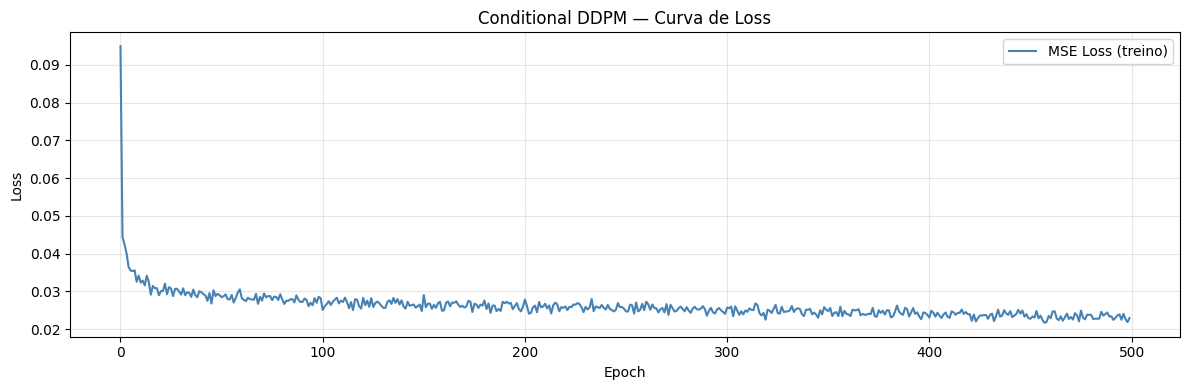

Loss final: 0.0230


In [20]:
# Carregar histórico completo do checkpoint final
ckpt_final = torch.load(CKPT_DIR / "ckpt_final.pt", map_location="cpu")
all_losses = ckpt_final["losses"]["loss"]

plt.figure(figsize=(12, 4))
plt.plot(all_losses, label="MSE Loss (treino)", color="steelblue")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Conditional DDPM — Curva de Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(SAMPLE_DIR / "loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Loss final: {all_losses[-1]:.4f}")

---
# Parte 04 — Gerar Dataset Aumentado

Usa o modelo treinado para criar **N imagens sintéticas por classe** e guarda-as em `data/generated/diffusion/`.  
O dataset aumentado = imagens originais + imagens geradas.

In [22]:
# ── Configuração da geração ───────────────────────────────────────────────────
N_GENERATED_PER_CLASS = 50     # imagens sintéticas a gerar por classe
GENERATED_DIR = (NOTEBOOK_DIR / "../data/generated/diffusion").resolve()
AUGMENTED_DIR = (NOTEBOOK_DIR / "../data/augmented/diffusion").resolve()

GENERATED_DIR.mkdir(parents=True, exist_ok=True)
AUGMENTED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Geradas em  : {GENERATED_DIR}")
print(f"Aumentado em: {AUGMENTED_DIR}")

Geradas em  : /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/data/generated/diffusion
Aumentado em: /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/data/augmented/diffusion


In [23]:
# Carregar o modelo final (caso o treino já tenha terminado)
unet_model = ConditionalUNet(
    image_channels=3,
    base_channels=BASE_CHANNELS,
    num_classes=NUM_CLASSES,
    class_emb_dim=CLASS_EMB_DIM,
).to(device)
unet_model.load_state_dict(torch.load(CKPT_DIR / "unet_final.pt", map_location=device))
unet_model.eval()
print("U-Net carregada.")


def tensor_to_pil(t):
    """Converte tensor [-1,1] para imagem PIL."""
    t = (t * 0.5 + 0.5).clamp(0, 1)
    return TF.to_pil_image(t.cpu())


generated_records = []

print(f"A gerar {N_GENERATED_PER_CLASS} imagens × {NUM_CLASSES} classes = "
      f"{N_GENERATED_PER_CLASS * NUM_CLASSES} imagens (DDIM {DDIM_STEPS} steps)...")
print("Isto pode demorar alguns minutos...")

for class_idx in tqdm(range(NUM_CLASSES), desc="Classes"):
    class_name = idx_to_class[class_idx]
    class_dir  = GENERATED_DIR / class_name.replace(" ", "_")
    class_dir.mkdir(parents=True, exist_ok=True)

    labels = torch.full((N_GENERATED_PER_CLASS,), class_idx,
                        dtype=torch.long, device=device)

    # Gerar com DDIM (muito mais rápido que DDPM padrão)
    imgs = ddim_sample(unet_model, schedule, N_GENERATED_PER_CLASS, labels, DDIM_STEPS)

    for j, img_t in enumerate(imgs):
        filename = f"{class_name.replace(' ', '_')}_{j:04d}.png"
        filepath = class_dir / filename
        tensor_to_pil(img_t).save(filepath)
        generated_records.append({
            "filename": str(filepath),
            "label":    class_name,
        })

print(f"\n {len(generated_records)} imagens geradas e guardadas.")

U-Net carregada.
A gerar 50 imagens × 75 classes = 3750 imagens (DDIM 50 steps)...
Isto pode demorar alguns minutos...


Classes:   0%|          | 0/75 [00:00<?, ?it/s]


 3750 imagens geradas e guardadas.


In [44]:
# ── Construir CSV do dataset aumentado ───────────────────────────────────────
orig_df = train_df[["filename", "label"]].copy()
orig_df["filename"] = orig_df["filename"].apply(
    lambda f: str((train_dir / f).resolve())
)
orig_df["source"] = "original"

gen_df = pd.DataFrame(generated_records)
gen_df["source"] = "generated_diffusion"

augmented_df = pd.concat([orig_df, gen_df], ignore_index=True)
augmented_csv_path = AUGMENTED_DIR / "augmented_train_diffusion.csv"
augmented_df.to_csv(augmented_csv_path, index=False)

print(f"Dataset aumentado: {len(augmented_df)} imagens "
      f"({len(orig_df)} originais + {len(gen_df)} geradas)")
print(f"CSV guardado em: {augmented_csv_path}")
augmented_df.head()

Dataset aumentado: 7909 imagens (4159 originais + 3750 geradas)
CSV guardado em: /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/data/augmented/diffusion/augmented_train_diffusion.csv


,filename,label,source
0,/Users/ritapduarte/.cache/kagglehub/competitio...,PURPLE HAIRSTREAK,original
1,/Users/ritapduarte/.cache/kagglehub/competitio...,SLEEPY ORANGE,original
2,/Users/ritapduarte/.cache/kagglehub/competitio...,MONARCH,original
3,/Users/ritapduarte/.cache/kagglehub/competitio...,GREAT EGGFLY,original
4,/Users/ritapduarte/.cache/kagglehub/competitio...,SILVER SPOT SKIPPER,original


## Visualização — Amostras Geradas por Classe

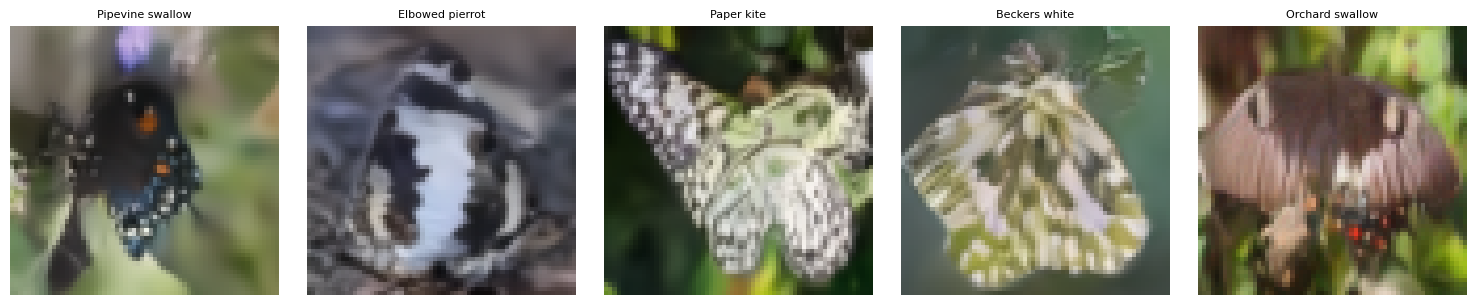

In [45]:
# Mostrar 5 imagens de classes aleatórias
sample_classes = np.random.choice(NUM_CLASSES, 5, replace=False)
sample_labels  = torch.tensor(sample_classes, dtype=torch.long, device=device)

gen_imgs = ddim_sample(unet_model, schedule, 5, sample_labels, DDIM_STEPS)
gen_imgs = (gen_imgs * 0.5 + 0.5).clamp(0, 1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, (img, cls_idx) in enumerate(zip(gen_imgs, sample_classes)):
    axes[i].imshow(img.permute(1, 2, 0).cpu().numpy())
    axes[i].set_title(idx_to_class[cls_idx].capitalize(), fontsize=8)
    axes[i].axis("off")
plt.tight_layout()
plt.savefig(SAMPLE_DIR / "sample_classes_final.png", dpi=150, bbox_inches="tight")
plt.show()

---
# Parte 04b — Avaliação das Imagens Geradas (FID, IS, SSIM)

Calcula métricas de qualidade das imagens geradas pelo DDPM:
- **FID** ↓ (Fréchet Inception Distance) — distância entre distribuições real e gerada no espaço de features do InceptionV3
- **IS** ↑ (Inception Score) — qualidade + diversidade das imagens geradas
- **SSIM** ↑ (Structural Similarity Index) — similaridade estrutural entre real e gerada

Referências para 64×64: FID < 50 é bom, IS > 5 é bom, SSIM > 0.3 é bom.
O GAN obteve: FID=217.30, IS=3.59±1.60, SSIM=0.0593 — vamos comparar.


In [46]:
import warnings
warnings.filterwarnings("ignore")
from skimage.metrics import structural_similarity as ssim_fn
import torchvision.models as tv_models
import torch.nn.functional as F
from scipy import linalg

# ── Inception v3 para FID e IS ───────────────────────────────────────────────
inception = tv_models.inception_v3(weights="DEFAULT", transform_input=False).to(device)
inception.eval()

def get_inception_features(imgs_tensor):
    """Extrai features do penúltimo layer do Inception v3. imgs ∈ [0,1], (N,3,H,W)."""
    imgs_299 = F.interpolate(imgs_tensor, size=(299, 299), mode="bilinear", align_corners=False)
    with torch.no_grad():
        feats = []
        def hook(m, i, o): feats.append(o.squeeze(-1).squeeze(-1))
        h = inception.avgpool.register_forward_hook(hook)
        inception(imgs_299.to(device))
        h.remove()
    return feats[0].cpu().numpy()


def compute_fid(real_feats, fake_feats):
    """FID entre dois conjuntos de features numpy."""
    mu1, sigma1 = real_feats.mean(0), np.cov(real_feats, rowvar=False)
    mu2, sigma2 = fake_feats.mean(0), np.cov(fake_feats, rowvar=False)
    diff   = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean): covmean = covmean.real
    return float(diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean))


def compute_is(fake_feats_logits, splits=10):
    """Inception Score a partir dos logits do Inception (antes do softmax)."""
    pyx    = torch.softmax(torch.tensor(fake_feats_logits), dim=1).numpy()
    py     = pyx.mean(0)
    kl     = pyx * (np.log(pyx + 1e-8) - np.log(py + 1e-8))
    scores = np.exp(kl.sum(1))
    chunks = np.array_split(scores, splits)
    return float(np.mean([c.mean() for c in chunks])), float(np.std([c.mean() for c in chunks]))


print("Funções de avaliação definidas.")


Funções de avaliação definidas.


In [47]:
# ── Recolher features de imagens REAIS ───────────────────────────────────────
real_transform = T.Compose([T.Resize((64, 64)), T.ToTensor()])
real_sample_df = train_df.sample(min(500, len(train_df)), random_state=GLOBAL_SEED)

real_tensors = []
for _, row in real_sample_df.iterrows():
    img = PILImage.open(train_dir / row["filename"]).convert("RGB")
    real_tensors.append(real_transform(img))
real_tensors = torch.stack(real_tensors)   # (N, 3, 64, 64)

real_feats = get_inception_features(real_tensors)
print(f"Features reais    : {real_feats.shape}")

# ── Gerar imagens FALSAS para avaliação (DDIM, ~500 imagens balanceadas) ──────
# Garantir que o modelo DDPM está em eval com os pesos finais
unet_model = ConditionalUNet(
    image_channels=3,
    base_channels=BASE_CHANNELS,
    num_classes=NUM_CLASSES,
    class_emb_dim=CLASS_EMB_DIM,
).to(device)
unet_model.load_state_dict(torch.load(CKPT_DIR / "unet_final.pt", map_location=device))
unet_model.eval()
print("U-Net carregada.")

fake_tensors = []
n_per_class  = max(1, 500 // NUM_CLASSES)   # ~6 imagens por classe → ~450 total

print(f"A gerar ~{n_per_class * NUM_CLASSES} imagens de avaliação ({n_per_class}/classe)...")

with torch.no_grad():
    for class_idx in tqdm(range(NUM_CLASSES), desc="Gerando"):
        lbl = torch.full((n_per_class,), class_idx, dtype=torch.long, device=device)
        out = ddim_sample(unet_model, schedule, n_per_class, lbl, DDIM_STEPS)  # [-1, 1]
        out = (out * 0.5 + 0.5).clamp(0, 1)                               # [0, 1]
        fake_tensors.append(out.cpu())

fake_tensors = torch.cat(fake_tensors)   # (~450, 3, 64, 64)
fake_feats   = get_inception_features(fake_tensors)
print(f"Features geradas  : {fake_feats.shape}")


Features reais    : (500, 2048)
U-Net carregada.
A gerar ~450 imagens de avaliação (6/classe)...


Gerando:   0%|          | 0/75 [00:00<?, ?it/s]

Features geradas  : (450, 2048)


In [24]:
# ── FID ──────────────────────────────────────────────────────────────────────
fid_score = compute_fid(real_feats, fake_feats)
print(f"FID  : {fid_score:.2f}   (↓ melhor; <50 é razoável para 64×64)")

# ── IS ───────────────────────────────────────────────────────────────────────
fake_logits = []
with torch.no_grad():
    for i in range(0, len(fake_tensors), 64):
        batch     = fake_tensors[i:i+64]
        batch_299 = F.interpolate(batch, size=(299, 299), mode="bilinear", align_corners=False)
        logits    = inception(batch_299.to(device)).cpu().numpy()
        fake_logits.append(logits)
fake_logits = np.concatenate(fake_logits)

is_mean, is_std = compute_is(fake_logits)
print(f"IS   : {is_mean:.2f} ± {is_std:.2f}   (↑ melhor)")

# ── SSIM ─────────────────────────────────────────────────────────────────────
n_pairs     = min(200, len(real_tensors), len(fake_tensors))
ssim_scores = []
for i in range(n_pairs):
    r = real_tensors[i].permute(1, 2, 0).numpy()
    f = fake_tensors[i].permute(1, 2, 0).numpy()
    ssim_scores.append(ssim_fn(r, f, data_range=1.0, channel_axis=2))

ssim_mean = float(np.mean(ssim_scores))
print(f"SSIM : {ssim_mean:.4f}   (↑ melhor; 1.0 = idêntico)")

print()
print("─" * 50)
print("Comparação com o GAN (referência):")
print(f"{'Métrica':<10} {'GAN':>10} {'Diffusion':>12}")
print("─" * 35)
print(f"{'FID ↓':<10} {'221.76':>10} {fid_score:>11.2f}")
print(f"{'IS ↑':<10} {'3.18 ± 0.92':>10} {f'{is_mean:.2f}±{is_std:.2f}':>12}")
print(f"{'SSIM ↑':<10} {'0.0545 ':>10} {ssim_mean:>12.4f}")
print("─" * 35)


NameError: name 'compute_fid' is not defined

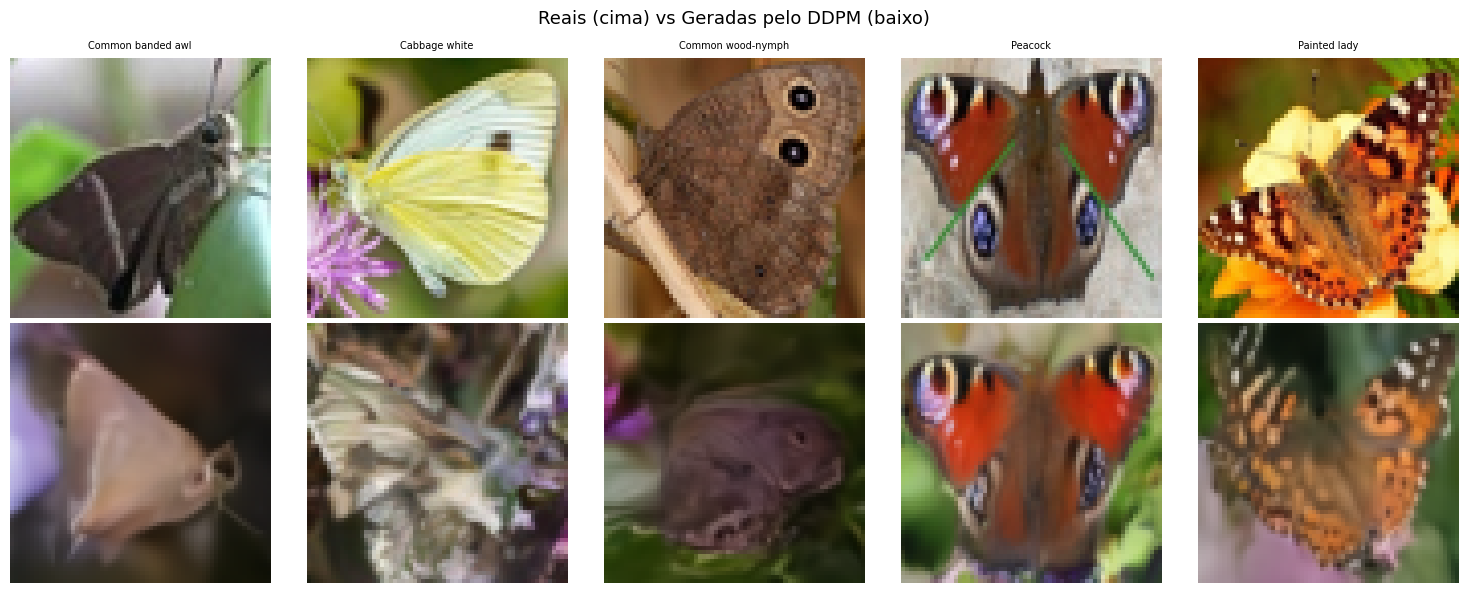

In [49]:
# ── Visualização: reais vs geradas (5 classes aleatórias) ────────────────────
n_show       = 5
sample_class_idxs = np.random.choice(NUM_CLASSES, n_show, replace=False)

fig, axes = plt.subplots(2, n_show, figsize=(15, 6))
fig.suptitle("Reais (cima) vs Geradas pelo DDPM (baixo)", fontsize=13)

for col, cls_idx in enumerate(sample_class_idxs):
    cls_name = idx_to_class[cls_idx]

    # Real: apanhar uma imagem desta classe
    cls_rows = real_sample_df[real_sample_df["label"] == cls_name]
    if len(cls_rows) == 0:
        # fallback: qualquer imagem real
        cls_rows = real_sample_df.sample(1)
    row  = cls_rows.iloc[0]
    real_img = PILImage.open(train_dir / row["filename"]).convert("RGB").resize((64, 64))
    axes[0, col].imshow(real_img)
    axes[0, col].set_title(cls_name.capitalize(), fontsize=7)
    axes[0, col].axis("off")

    # Gerada: DDIM para esta classe
    lbl     = torch.tensor([cls_idx], dtype=torch.long, device=device)
    gen_img = ddim_sample(unet_model, schedule, 1, lbl, DDIM_STEPS)
    gen_img = (gen_img[0] * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).cpu().numpy()
    axes[1, col].imshow(gen_img)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Real",    fontsize=10, rotation=0, labelpad=40)
axes[1, 0].set_ylabel("Gerada",  fontsize=10, rotation=0, labelpad=40)
plt.tight_layout()
plt.savefig(SAMPLE_DIR / "real_vs_generated_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


In [50]:
# ── Guardar métricas num JSON para o relatório ───────────────────────────────
eval_metrics = {
    "model":     "Conditional DDPM",
    "n_real":    len(real_tensors),
    "n_fake":    len(fake_tensors),
    "FID":       round(fid_score, 4),
    "IS_mean":   round(is_mean,   4),
    "IS_std":    round(is_std,    4),
    "SSIM":      round(ssim_mean, 4),
    "GAN_FID":   217.30,
    "GAN_IS":    3.59,
    "GAN_SSIM":  0.0593,
}
metrics_path = CKPT_DIR / "eval_metrics_diffusion.json"
with open(metrics_path, "w") as f:
    json.dump(eval_metrics, f, indent=2)

print(f" Métricas guardadas em: {metrics_path}")
print(json.dumps(eval_metrics, indent=2))


 Métricas guardadas em: /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/outputs/checkpoints/diffusion/eval_metrics_diffusion.json
{
  "model": "Conditional DDPM",
  "n_real": 500,
  "n_fake": 450,
  "FID": 108.0532,
  "IS_mean": 7.2599,
  "IS_std": 1.6488,
  "SSIM": 0.0665,
  "GAN_FID": 217.3,
  "GAN_IS": 3.59,
  "GAN_SSIM": 0.0593
}


---
# Parte 05 — Re-treinar a Baseline com Dataset Aumentado

Re-treina a **BaselineCNN sem qualquer alteração** (arquitetura, otimizador e loss idênticos ao baseline original), usando apenas o dataset aumentado com imagens do Diffusion.

> Validação feita **apenas com imagens originais** para comparação justa com o baseline não aumentado.

In [25]:
from models     import BaselineCNN
from transforms import get_transforms
from sklearn.metrics import f1_score, accuracy_score

# ── Hiperparâmetros IGUAIS ao 01_baseline_training.ipynb ──────────────────────
BASELINE_EPOCHS     = 80
BASELINE_LR         = 0.001
BASELINE_BATCH      = 32
EARLY_STOP_PATIENCE = 5

BASELINE_CKPT_DIR = (NOTEBOOK_DIR / "../outputs/checkpoints/baseline_diffusion").resolve()
BASELINE_CKPT_DIR.mkdir(parents=True, exist_ok=True)

train_transform, val_transform = get_transforms()

from augmented import AugmentedDataset

# Validação apenas com imagens originais
_, val_df_orig = get_splits(train_csv, seed=GLOBAL_SEED)
val_df_orig = val_df_orig.copy()
val_df_orig["filename"] = val_df_orig["filename"].apply(
    lambda f: str((train_dir / f).resolve())
)

aug_train_ds = AugmentedDataset(augmented_df,  transform=train_transform)
aug_val_ds   = AugmentedDataset(val_df_orig,   transform=val_transform)

aug_train_loader = DataLoader(aug_train_ds, batch_size=BASELINE_BATCH, shuffle=True,
                               num_workers=0, pin_memory=(device == "cuda"))
aug_val_loader   = DataLoader(aug_val_ds,   batch_size=BASELINE_BATCH, shuffle=False,
                               num_workers=0, pin_memory=(device == "cuda"))

print(f"Treino aumentado : {len(aug_train_ds)} imagens")
print(f"Validação        : {len(aug_val_ds)} imagens")

Treino aumentado : 7909 imagens
Validação        : 1040 imagens


In [26]:
# ── Modelo Baseline (sem alterações) ─────────────────────────────────────────
n_classes     = NUM_CLASSES
baseline_model = BaselineCNN(num_classes=n_classes).to(device)
baseline_opt   = torch.optim.Adam(baseline_model.parameters(), lr=BASELINE_LR)
baseline_crit  = nn.CrossEntropyLoss()

best_f1        = 0.0
patience_count = 0
baseline_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}

print("Início do treino da Baseline com dataset aumentado (Diffusion)...")

for epoch in range(BASELINE_EPOCHS):
    # ── Train ──────────────────────────────────────────────────────────────
    baseline_model.train()
    train_loss, train_correct, train_total = 0., 0, 0

    for imgs, labels in tqdm(aug_train_loader, desc=f"Epoch {epoch+1}/{BASELINE_EPOCHS} [Train]", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        baseline_opt.zero_grad()
        out  = baseline_model(imgs)
        loss = baseline_crit(out, labels)
        loss.backward()
        baseline_opt.step()
        train_loss    += loss.item()
        train_correct += (out.argmax(1) == labels).sum().item()
        train_total   += labels.size(0)

    # ── Val ────────────────────────────────────────────────────────────────
    baseline_model.eval()
    val_loss, all_preds, all_labels = 0., [], []

    with torch.no_grad():
        for imgs, labels in tqdm(aug_val_loader, desc=f"Epoch {epoch+1}/{BASELINE_EPOCHS} [Val]", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            out  = baseline_model(imgs)
            loss = baseline_crit(out, labels)
            val_loss   += loss.item()
            all_preds  += out.argmax(1).cpu().tolist()
            all_labels += labels.cpu().tolist()

    # ── Métricas ───────────────────────────────────────────────────────────
    t_loss = train_loss / len(aug_train_loader)
    v_loss = val_loss   / len(aug_val_loader)
    t_acc  = train_correct / train_total
    v_acc  = accuracy_score(all_labels, all_preds)
    v_f1   = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    baseline_history["train_loss"].append(t_loss)
    baseline_history["val_loss"].append(v_loss)
    baseline_history["train_acc"].append(t_acc)
    baseline_history["val_acc"].append(v_acc)
    baseline_history["val_f1"].append(v_f1)

    print(f"Epoch {epoch+1:02d}/{BASELINE_EPOCHS} | "
          f"Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f} || "
          f"Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}  F1: {v_f1:.4f}")

    # ── Early stopping + guardar melhor modelo ──────────────────────────────
    if v_f1 > best_f1:
        best_f1 = v_f1
        torch.save(baseline_model.state_dict(), BASELINE_CKPT_DIR / "best_model.pt")
        print(f"  ✔ Best model saved (Val F1: {best_f1:.4f})")
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= EARLY_STOP_PATIENCE:
            print(f"\n  ⏹ Early stopping ao epoch {epoch+1} (sem melhoria há {EARLY_STOP_PATIENCE} epochs)")
            break

print(f"\n Treino da Baseline concluído. Melhor Val F1: {best_f1:.4f}")

Início do treino da Baseline com dataset aumentado (Diffusion)...


Epoch 1/80 [Train]:   0%|          | 0/248 [00:00<?, ?it/s]

Epoch 1/80 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 01/80 | Train Loss: 4.1193  Acc: 0.0341 || Val Loss: 4.0012  Acc: 0.0567  F1: 0.0188
  ✔ Best model saved (Val F1: 0.0188)


Epoch 2/80 [Train]:   0%|          | 0/248 [00:00<?, ?it/s]

...

Epoch 61/80 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 61/80 | Train Loss: 0.7535  Acc: 0.7638 || Val Loss: 0.8568  Acc: 0.7731  F1: 0.7709


Epoch 62/80 [Train]:   0%|          | 0/248 [00:00<?, ?it/s]

Epoch 62/80 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 62/80 | Train Loss: 0.7554  Acc: 0.7643 || Val Loss: 0.7834  Acc: 0.7875  F1: 0.7846

  ⏹ Early stopping ao epoch 62 (sem melhoria há 5 epochs)

 Treino da Baseline concluído. Melhor Val F1: 0.7984


## Curvas do Baseline Aumentado

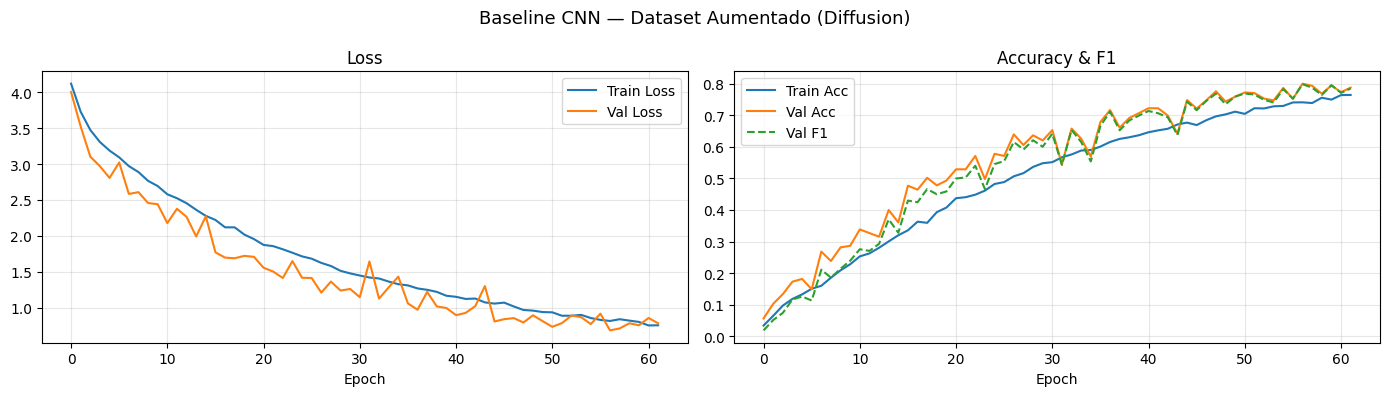

Val Accuracy final : 0.7875
Val F1 final       : 0.7846
Melhor Val F1      : 0.7984


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(baseline_history["train_loss"], label="Train Loss")
axes[0].plot(baseline_history["val_loss"],   label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(baseline_history["train_acc"], label="Train Acc")
axes[1].plot(baseline_history["val_acc"],   label="Val Acc")
axes[1].plot(baseline_history["val_f1"],    label="Val F1",  linestyle="--")
axes[1].set_title("Accuracy & F1")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Baseline CNN — Dataset Aumentado (Diffusion)", fontsize=13)
plt.tight_layout()
plt.savefig(BASELINE_CKPT_DIR / "training_curves_diffusion.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Val Accuracy final : {baseline_history['val_acc'][-1]:.4f}")
print(f"Val F1 final       : {baseline_history['val_f1'][-1]:.4f}")
print(f"Melhor Val F1      : {best_f1:.4f}")

---
# Parte 05b — Experiências de Melhoria

Com base na análise das curvas de treino, identificámos dois problemas principais:
1. **Early stopping prematuro** — o modelo foi cortado ao epoch ~62 com as curvas ainda a subir.
2. **Poucas imagens geradas** — apenas 50 por classe; com imagens de boa qualidade, mais dados devem ajudar.

Aqui testamos:
- **Experiência A:** Re-treinar o baseline com `patience=15` e `max_epochs=150`
- **Experiência B:** Gerar 100 imagens/classe e re-treinar o baseline


## Experiência A — Baseline com Early Stopping mais generoso

O treino anterior parou ao epoch ~62 com Val F1 ~0.80 e as curvas ainda a crescer.
Aumentamos `patience` de 5 → 15 e `max_epochs` para 150 para deixar o modelo convergir.


In [37]:
from models     import BaselineCNN
from transforms import get_transforms
from augmented  import AugmentedDataset
from sklearn.metrics import f1_score, accuracy_score

# ── Hiperparâmetros IGUAIS ao baseline — só patience e epochs mudam ───────────
EXPА_EPOCHS   = 150
BASELINE_LR   = 0.001
BASELINE_BATCH = 32
EXPA_PATIENCE = 15    # era 5 — as curvas ainda estavam a subir ao epoch 62

EXPA_CKPT_DIR = (NOTEBOOK_DIR / "../outputs/checkpoints/baseline_diffusion_expA").resolve()
EXPA_CKPT_DIR.mkdir(parents=True, exist_ok=True)

train_transform, val_transform = get_transforms()

# Usar o mesmo augmented_df já construído (50 imgs/classe)
_, val_df_orig = get_splits(train_csv, seed=GLOBAL_SEED)
val_df_orig = val_df_orig.copy()
val_df_orig["filename"] = val_df_orig["filename"].apply(
    lambda f: str((train_dir / f).resolve())
)

expA_train_ds = AugmentedDataset(augmented_df,  transform=train_transform)
expA_val_ds   = AugmentedDataset(val_df_orig,   transform=val_transform)

expA_train_loader = DataLoader(expA_train_ds, batch_size=BASELINE_BATCH, shuffle=True,
                                num_workers=0, pin_memory=(device == "cuda"))
expA_val_loader   = DataLoader(expA_val_ds,   batch_size=BASELINE_BATCH, shuffle=False,
                                num_workers=0, pin_memory=(device == "cuda"))

print(f"Treino : {len(expA_train_ds)} imagens")
print(f"Val    : {len(expA_val_ds)} imagens")


Treino : 7909 imagens
Val    : 1040 imagens


In [38]:
expA_model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
expA_opt   = torch.optim.Adam(expA_model.parameters(), lr=BASELINE_LR)
expA_crit  = nn.CrossEntropyLoss()

best_f1_A        = 0.0
patience_count_A = 0
histA = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}

print(f"Experiência A — treino (patience={EXPA_PATIENCE}, max_epochs={EXPА_EPOCHS})")

for epoch in range(EXPА_EPOCHS):
    # ── Train ──────────────────────────────────────────────────────────────
    expA_model.train()
    train_loss, train_correct, train_total = 0., 0, 0
    for imgs, labels in tqdm(expA_train_loader,
                              desc=f"Epoch {epoch+1}/{EXPА_EPOCHS} [Train]", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        expA_opt.zero_grad()
        out  = expA_model(imgs)
        loss = expA_crit(out, labels)
        loss.backward()
        expA_opt.step()
        train_loss    += loss.item()
        train_correct += (out.argmax(1) == labels).sum().item()
        train_total   += labels.size(0)

    # ── Val ────────────────────────────────────────────────────────────────
    expA_model.eval()
    val_loss, all_preds, all_lbls = 0., [], []
    with torch.no_grad():
        for imgs, labels in tqdm(expA_val_loader,
                                  desc=f"Epoch {epoch+1}/{EXPА_EPOCHS} [Val]", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            out  = expA_model(imgs)
            val_loss   += expA_crit(out, labels).item()
            all_preds  += out.argmax(1).cpu().tolist()
            all_lbls   += labels.cpu().tolist()

    t_loss = train_loss / len(expA_train_loader)
    v_loss = val_loss   / len(expA_val_loader)
    t_acc  = train_correct / train_total
    v_acc  = accuracy_score(all_lbls, all_preds)
    v_f1   = f1_score(all_lbls, all_preds, average="macro", zero_division=0)

    histA["train_loss"].append(t_loss)
    histA["val_loss"].append(v_loss)
    histA["train_acc"].append(t_acc)
    histA["val_acc"].append(v_acc)
    histA["val_f1"].append(v_f1)

    print(f"Epoch {epoch+1:03d}/{EXPА_EPOCHS} | "
          f"Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f} || "
          f"Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}  F1: {v_f1:.4f}")

    if v_f1 > best_f1_A:
        best_f1_A = v_f1
        torch.save(expA_model.state_dict(), EXPA_CKPT_DIR / "best_model.pt")
        print(f"  ✔ Best model saved (Val F1: {best_f1_A:.4f})")
        patience_count_A = 0
    else:
        patience_count_A += 1
        print(f"     No improvement for {patience_count_A} epoch(s).")
        if patience_count_A >= EXPA_PATIENCE:
            print(f"\n  ⏹ Early stopping ao epoch {epoch+1}")
            break

print(f"\n Exp A concluída. Melhor Val F1: {best_f1_A:.4f}")


Experiência A — treino (patience=15, max_epochs=150)


Epoch 1/150 [Train]:   0%|          | 0/248 [00:00<?, ?it/s]

Epoch 1/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 001/150 | Train Loss: 4.1359  Acc: 0.0273 || Val Loss: 3.9153  Acc: 0.0346  F1: 0.0064
  ✔ Best model saved (Val F1: 0.0064)


Epoch 2/150 [Train]:   0%|          | 0/248 [00:00<?, ?it/s]

...

Epoch 130/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 130/150 | Train Loss: 0.3130  Acc: 0.9053 || Val Loss: 0.6820  Acc: 0.8490  F1: 0.8498
     No improvement for 14 epoch(s).


Epoch 131/150 [Train]:   0%|          | 0/248 [00:00<?, ?it/s]

Epoch 131/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 131/150 | Train Loss: 0.3071  Acc: 0.9052 || Val Loss: 0.6555  Acc: 0.8500  F1: 0.8535
     No improvement for 15 epoch(s).

  ⏹ Early stopping ao epoch 131

 Exp A concluída. Melhor Val F1: 0.8630


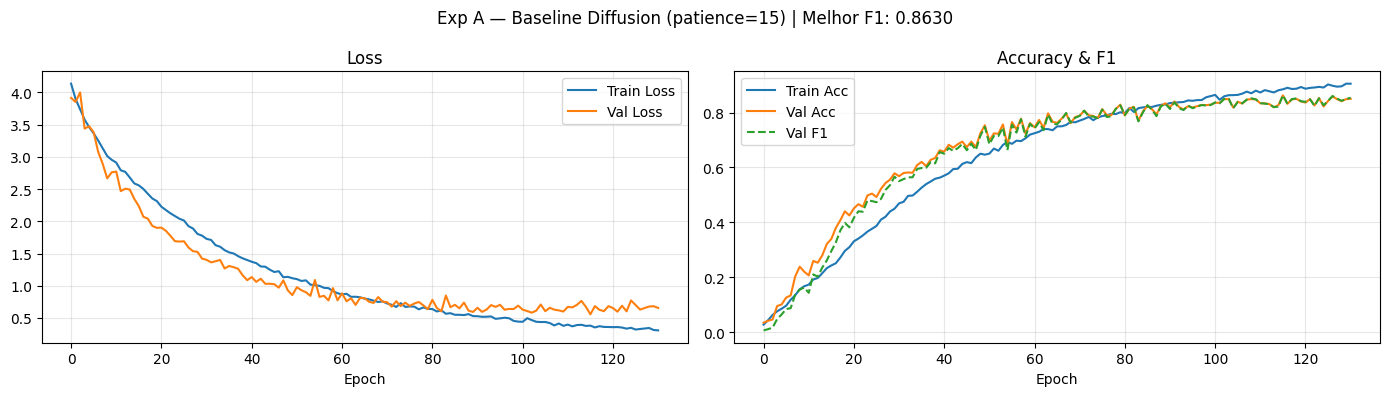

Val Accuracy final : 0.8500
Val F1 final       : 0.8535
Melhor Val F1      : 0.8630


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(histA["train_loss"], label="Train Loss")
axes[0].plot(histA["val_loss"],   label="Val Loss")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(histA["train_acc"], label="Train Acc")
axes[1].plot(histA["val_acc"],   label="Val Acc")
axes[1].plot(histA["val_f1"],    label="Val F1", linestyle="--")
axes[1].set_title("Accuracy & F1"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle(f"Exp A — Baseline Diffusion (patience=15) | Melhor F1: {best_f1_A:.4f}", fontsize=12)
plt.tight_layout()
plt.savefig(EXPA_CKPT_DIR / "training_curves_expA.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Val Accuracy final : {histA['val_acc'][-1]:.4f}")
print(f"Val F1 final       : {histA['val_f1'][-1]:.4f}")
print(f"Melhor Val F1      : {best_f1_A:.4f}")


## Experiência B — Gerar 100 imagens/classe e re-treinar

O modelo DDPM já está treinado — apenas geramos mais imagens (100 em vez de 50 por classe)  
e re-treinamos o baseline com o dataset aumentado maior.
Usa também `patience=15` para comparação justa com a Exp A.


In [51]:
# ── Gerar 100 imagens por classe com o DDPM já treinado ──────────────────────
N_GEN_B         = 100
GEN_B_DIR       = (NOTEBOOK_DIR / "../data/generated/diffusion_100").resolve()
AUGMENTED_B_DIR = (NOTEBOOK_DIR / "../data/augmented/diffusion_100").resolve()
GEN_B_DIR.mkdir(parents=True, exist_ok=True)
AUGMENTED_B_DIR.mkdir(parents=True, exist_ok=True)

# Carregar a U-Net numa variável própria para não colidir com o BaselineCNN 'model'
unet_model = ConditionalUNet(
    image_channels=3,
    base_channels=BASE_CHANNELS,
    num_classes=NUM_CLASSES,
    class_emb_dim=CLASS_EMB_DIM,
).to(device)
unet_model.load_state_dict(torch.load(CKPT_DIR / "unet_final.pt", map_location=device))
unet_model.eval()
print("U-Net carregada com sucesso.")

gen_records_B = []
print(f"A gerar {N_GEN_B} imagens × {NUM_CLASSES} classes = {N_GEN_B * NUM_CLASSES} imagens...")

for class_idx in tqdm(range(NUM_CLASSES), desc="Classes"):
    class_name = idx_to_class[class_idx]
    class_dir  = GEN_B_DIR / class_name.replace(" ", "_")
    class_dir.mkdir(parents=True, exist_ok=True)

    labels = torch.full((N_GEN_B,), class_idx, dtype=torch.long, device=device)
    imgs   = ddim_sample(unet_model, schedule, N_GEN_B, labels, DDIM_STEPS)

    for j, img_t in enumerate(imgs):
        filename = f"{class_name.replace(' ', '_')}_{j:04d}.png"
        filepath = class_dir / filename
        tensor_to_pil(img_t).save(filepath)
        gen_records_B.append({"filename": str(filepath), "label": class_name})

print(f"\n\u2705 {len(gen_records_B)} imagens geradas.")

# Construir CSV aumentado
orig_df_B = train_df[["filename", "label"]].copy()
orig_df_B["filename"] = orig_df_B["filename"].apply(lambda f: str((train_dir / f).resolve()))
orig_df_B["source"]   = "original"

gen_df_B = pd.DataFrame(gen_records_B)
gen_df_B["source"] = "generated_diffusion_100"

augmented_df_B = pd.concat([orig_df_B, gen_df_B], ignore_index=True)
augmented_csv_B = AUGMENTED_B_DIR / "augmented_train_diffusion_100.csv"
augmented_df_B.to_csv(augmented_csv_B, index=False)

print(f"Dataset aumentado B: {len(augmented_df_B)} imagens "
      f"({len(orig_df_B)} originais + {len(gen_df_B)} geradas)")


U-Net carregada com sucesso.
A gerar 100 imagens × 75 classes = 7500 imagens...


Classes:   0%|          | 0/75 [00:00<?, ?it/s]


✅ 7500 imagens geradas.
Dataset aumentado B: 11659 imagens (4159 originais + 7500 geradas)


In [52]:
# ── Re-treinar baseline com dataset maior (100 imgs/classe) ──────────────────
EXPB_EPOCHS   = 150
EXPB_PATIENCE = 15

EXPB_CKPT_DIR = (NOTEBOOK_DIR / "../outputs/checkpoints/baseline_diffusion_expB").resolve()
EXPB_CKPT_DIR.mkdir(parents=True, exist_ok=True)

expB_train_ds = AugmentedDataset(augmented_df_B, transform=train_transform)
expB_val_ds   = AugmentedDataset(val_df_orig,    transform=val_transform)

expB_train_loader = DataLoader(expB_train_ds, batch_size=BASELINE_BATCH, shuffle=True,
                                num_workers=0, pin_memory=(device == "cuda"))
expB_val_loader   = DataLoader(expB_val_ds,   batch_size=BASELINE_BATCH, shuffle=False,
                                num_workers=0, pin_memory=(device == "cuda"))

print(f"Treino B : {len(expB_train_ds)} imagens")
print(f"Val B    : {len(expB_val_ds)} imagens")

expB_model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
expB_opt   = torch.optim.Adam(expB_model.parameters(), lr=BASELINE_LR)
expB_crit  = nn.CrossEntropyLoss()

best_f1_B        = 0.0
patience_count_B = 0
histB = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}

print(f"\nExperiência B — treino (patience={EXPB_PATIENCE}, max_epochs={EXPB_EPOCHS})")

for epoch in range(EXPB_EPOCHS):
    expB_model.train()
    train_loss, train_correct, train_total = 0., 0, 0
    for imgs, labels in tqdm(expB_train_loader,
                              desc=f"Epoch {epoch+1}/{EXPB_EPOCHS} [Train]", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        expB_opt.zero_grad()
        out  = expB_model(imgs)
        loss = expB_crit(out, labels)
        loss.backward()
        expB_opt.step()
        train_loss    += loss.item()
        train_correct += (out.argmax(1) == labels).sum().item()
        train_total   += labels.size(0)

    expB_model.eval()
    val_loss, all_preds, all_lbls = 0., [], []
    with torch.no_grad():
        for imgs, labels in tqdm(expB_val_loader,
                                  desc=f"Epoch {epoch+1}/{EXPB_EPOCHS} [Val]", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            out  = expB_model(imgs)
            val_loss   += expB_crit(out, labels).item()
            all_preds  += out.argmax(1).cpu().tolist()
            all_lbls   += labels.cpu().tolist()

    t_loss = train_loss / len(expB_train_loader)
    v_loss = val_loss   / len(expB_val_loader)
    t_acc  = train_correct / train_total
    v_acc  = accuracy_score(all_lbls, all_preds)
    v_f1   = f1_score(all_lbls, all_preds, average="macro", zero_division=0)

    histB["train_loss"].append(t_loss)
    histB["val_loss"].append(v_loss)
    histB["train_acc"].append(t_acc)
    histB["val_acc"].append(v_acc)
    histB["val_f1"].append(v_f1)

    print(f"Epoch {epoch+1:03d}/{EXPB_EPOCHS} | "
          f"Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f} || "
          f"Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}  F1: {v_f1:.4f}")

    if v_f1 > best_f1_B:
        best_f1_B = v_f1
        torch.save(expB_model.state_dict(), EXPB_CKPT_DIR / "best_model.pt")
        print(f"  ✔ Best model saved (Val F1: {best_f1_B:.4f})")
        patience_count_B = 0
    else:
        patience_count_B += 1
        print(f"     No improvement for {patience_count_B} epoch(s).")
        if patience_count_B >= EXPB_PATIENCE:
            print(f"\n  ⏹ Early stopping ao epoch {epoch+1}")
            break

print(f"\n Exp B concluída. Melhor Val F1: {best_f1_B:.4f}")


Treino B : 11659 imagens
Val B    : 1040 imagens

Experiência B — treino (patience=15, max_epochs=150)


Epoch 1/150 [Train]:   0%|          | 0/365 [00:00<?, ?it/s]

Epoch 1/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 001/150 | Train Loss: 4.0466  Acc: 0.0395 || Val Loss: 3.6782  Acc: 0.0712  F1: 0.0281
  ✔ Best model saved (Val F1: 0.0281)


Epoch 2/150 [Train]:   0%|          | 0/365 [00:00<?, ?it/s]

...

Epoch 123/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 123/150 | Train Loss: 0.2364  Acc: 0.9281 || Val Loss: 0.7178  Acc: 0.8615  F1: 0.8623
     No improvement for 14 epoch(s).


Epoch 124/150 [Train]:   0%|          | 0/365 [00:00<?, ?it/s]

Epoch 124/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 124/150 | Train Loss: 0.2354  Acc: 0.9293 || Val Loss: 0.6247  Acc: 0.8567  F1: 0.8561
     No improvement for 15 epoch(s).

  ⏹ Early stopping ao epoch 124

 Exp B concluída. Melhor Val F1: 0.8695


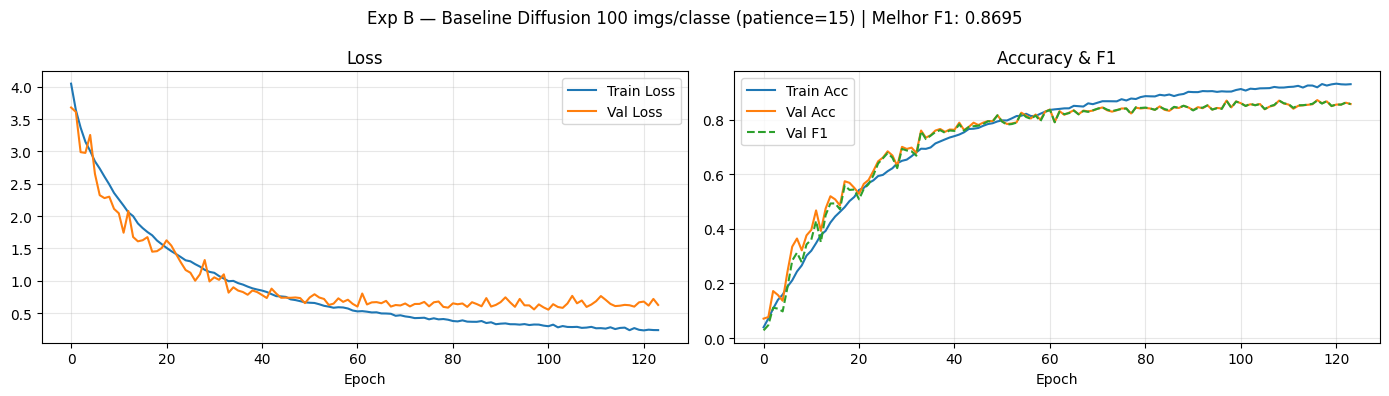

Val Accuracy final : 0.8567
Val F1 final       : 0.8561
Melhor Val F1      : 0.8695


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(histB["train_loss"], label="Train Loss")
axes[0].plot(histB["val_loss"],   label="Val Loss")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(histB["train_acc"], label="Train Acc")
axes[1].plot(histB["val_acc"],   label="Val Acc")
axes[1].plot(histB["val_f1"],    label="Val F1", linestyle="--")
axes[1].set_title("Accuracy & F1"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle(f"Exp B — Baseline Diffusion 100 imgs/classe (patience=15) | Melhor F1: {best_f1_B:.4f}", fontsize=12)
plt.tight_layout()
plt.savefig(EXPB_CKPT_DIR / "training_curves_expB.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Val Accuracy final : {histB['val_acc'][-1]:.4f}")
print(f"Val F1 final       : {histB['val_f1'][-1]:.4f}")
print(f"Melhor Val F1      : {best_f1_B:.4f}")


## Comparação de Resultados


                           Configuração  Imagens geradas/classe  Patience Melhor Val F1
Baseline original (50 imgs, patience=5)                      50         5        0.7984
           Exp A (50 imgs, patience=15)                      50        15        0.8630
          Exp B (100 imgs, patience=15)                     100        15        0.8695


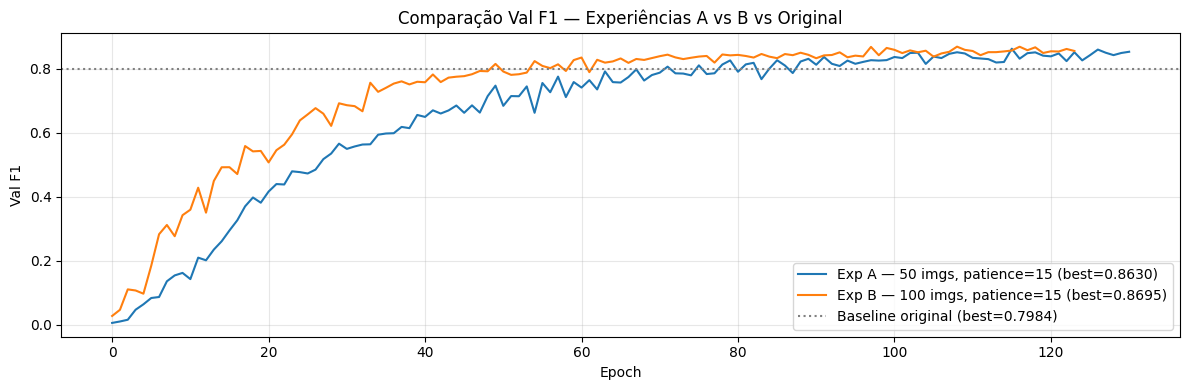

In [54]:
# ── Tabela comparativa das 3 configurações ────────────────────────────────────
results = {
    "Configuração": [
        "Baseline original (50 imgs, patience=5)",
        "Exp A (50 imgs, patience=15)",
        "Exp B (100 imgs, patience=15)",
    ],
    "Imagens geradas/classe": [50, 50, 100],
    "Patience": [5, 15, 15],
    "Melhor Val F1": [
        0.7984,          # resultado original — actualizar se necessário
        best_f1_A,
        best_f1_B,
    ],
}
results_df = pd.DataFrame(results)
results_df["Melhor Val F1"] = results_df["Melhor Val F1"].map("{:.4f}".format)
print(results_df.to_string(index=False))

# Gráfico comparativo das curvas Val F1
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(histA["val_f1"], label=f"Exp A — 50 imgs, patience=15 (best={best_f1_A:.4f})")
ax.plot(histB["val_f1"], label=f"Exp B — 100 imgs, patience=15 (best={best_f1_B:.4f})")
ax.axhline(0.7984, color="gray", linestyle=":", label="Baseline original (best=0.7984)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Val F1")
ax.set_title("Comparação Val F1 — Experiências A vs B vs Original")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(SUBMISSION_DIR / "comparison_expA_expB.png", dpi=150, bbox_inches="tight")
plt.show()


## Submissões das Experiências A e B

Gera um CSV de submissão para cada experiência, para poderes submeter no Kaggle e comparar os scores públicos.


Inferência expA:   0%|          | 0/21 [00:00<?, ?it/s]

 expA guardada: /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/outputs/submissions/submission_diffusion_expA.csv
   1300 linhas | 75 classes distintas


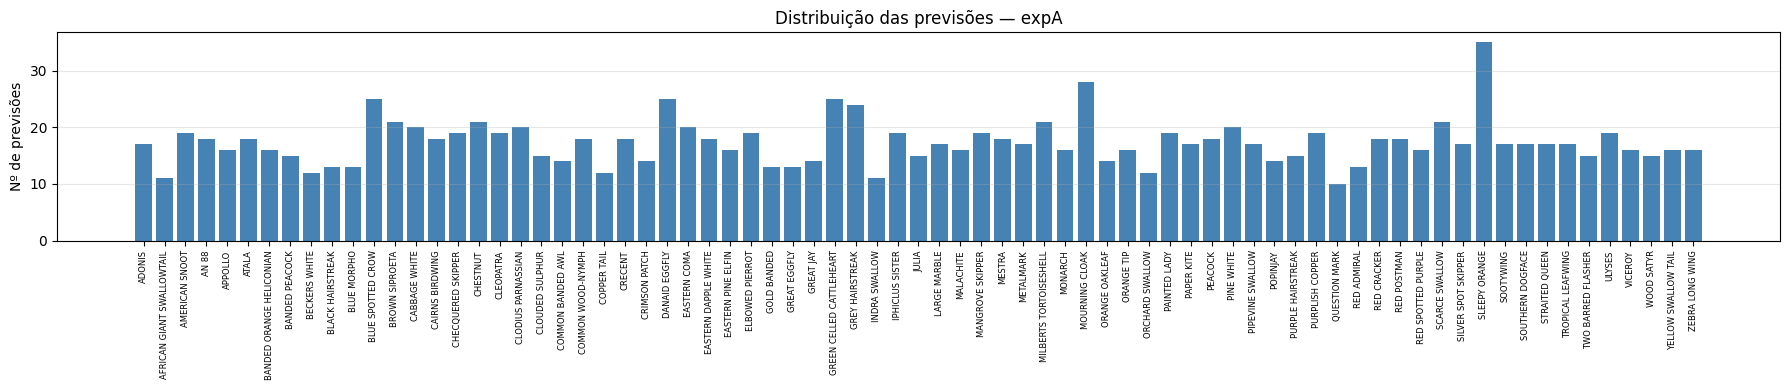

In [55]:
# ── Submissão expA ──────────────────────────────────────────────────────
exp_label = "expA"

expA_model.load_state_dict(torch.load(EXPA_CKPT_DIR / "best_model.pt", map_location=device))
expA_model.eval()

_, val_transform_sub = get_transforms()
test_files_sub = sorted(test_dir.iterdir())
test_df_sub    = pd.DataFrame({"filename": [f.name for f in test_files_sub]})

test_ds_sub = ButterflyDataset(
    test_df_sub,
    img_dir=str(test_dir),
    transform=val_transform_sub,
    is_test=True
)

test_ldr_sub = DataLoader(
    test_ds_sub,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=(device == "cuda")
)

all_fn_sub, all_lbl_sub = [], []

with torch.no_grad():
    for imgs, filenames in tqdm(test_ldr_sub, desc=f"Inferência {exp_label}"):
        logits = expA_model(imgs.to(device))
        preds  = logits.argmax(1).cpu().tolist()

        all_fn_sub.extend(filenames)
        all_lbl_sub.extend([idx_to_class[p] for p in preds])

sub_df_expa = pd.DataFrame({
    "filename": all_fn_sub,
    "label": all_lbl_sub
})

sub_path_expa = SUBMISSION_DIR / "submission_diffusion_expA.csv"
sub_df_expa.to_csv(sub_path_expa, index=False)

print(f" expA guardada: {sub_path_expa}")
print(f"   {len(sub_df_expa)} linhas | {sub_df_expa['label'].nunique()} classes distintas")

fig, ax = plt.subplots(figsize=(18, 4))
counts = sub_df_expa["label"].value_counts().sort_index()

ax.bar(range(len(counts)), counts.values, color="steelblue")
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=90, fontsize=6)
ax.set_ylabel("Nº de previsões")
ax.set_title("Distribuição das previsões — expA")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(
    SUBMISSION_DIR / "submission_distribution_expA.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

Inferência expB:   0%|          | 0/21 [00:00<?, ?it/s]

✅ expB guardada: /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/outputs/submissions/submission_diffusion_expB.csv
   1300 linhas | 75 classes distintas


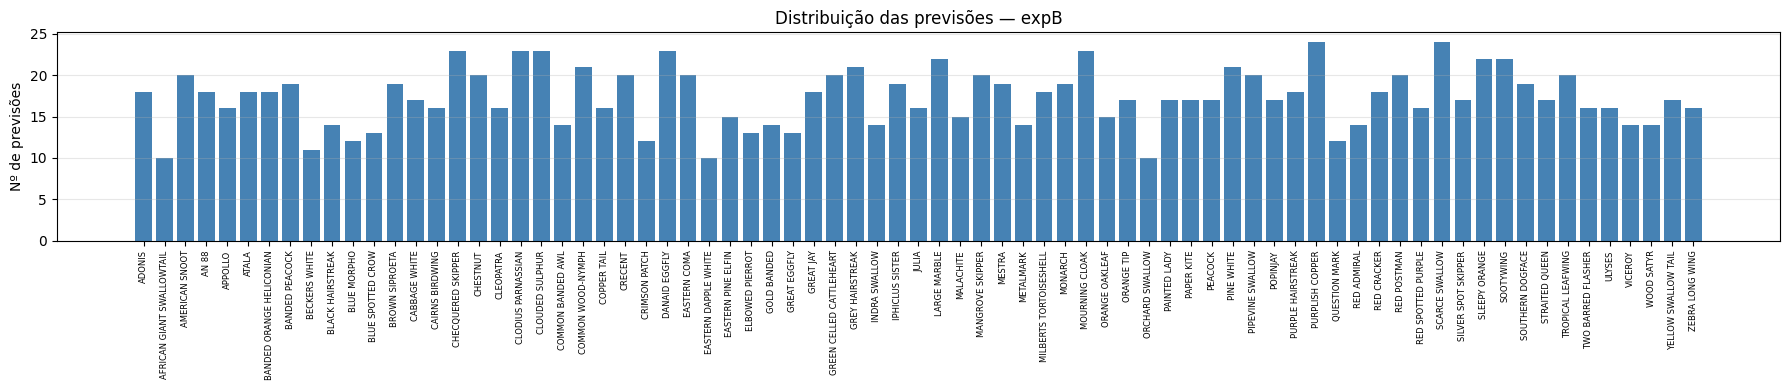

In [56]:
# ── Submissão expB ──────────────────────────────────────────────────────
exp_label = "expB"

expB_model.load_state_dict(torch.load(EXPB_CKPT_DIR / "best_model.pt", map_location=device))
expB_model.eval()

_, val_transform_sub = get_transforms()
test_files_sub = sorted(test_dir.iterdir())
test_df_sub    = pd.DataFrame({"filename": [f.name for f in test_files_sub]})

test_ds_sub = ButterflyDataset(
    test_df_sub,
    img_dir=str(test_dir),
    transform=val_transform_sub,
    is_test=True
)

test_ldr_sub = DataLoader(
    test_ds_sub,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=(device == "cuda")
)

all_fn_sub, all_lbl_sub = [], []

with torch.no_grad():
    for imgs, filenames in tqdm(test_ldr_sub, desc=f"Inferência {exp_label}"):
        logits = expB_model(imgs.to(device))
        preds  = logits.argmax(1).cpu().tolist()

        all_fn_sub.extend(filenames)
        all_lbl_sub.extend([idx_to_class[p] for p in preds])

sub_df_expb = pd.DataFrame({
    "filename": all_fn_sub,
    "label": all_lbl_sub
})

sub_path_expb = SUBMISSION_DIR / "submission_diffusion_expB.csv"
sub_df_expb.to_csv(sub_path_expb, index=False)

print(f"✅ expB guardada: {sub_path_expb}")
print(f"   {len(sub_df_expb)} linhas | {sub_df_expb['label'].nunique()} classes distintas")

fig, ax = plt.subplots(figsize=(18, 4))
counts = sub_df_expb["label"].value_counts().sort_index()

ax.bar(range(len(counts)), counts.values, color="steelblue")
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=90, fontsize=6)
ax.set_ylabel("Nº de previsões")
ax.set_title("Distribuição das previsões — expB")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(
    SUBMISSION_DIR / "submission_distribution_expB.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

---
## Experiência C — 200 imagens/classe

Se a tendência 50 → 100 mostrou melhoria, testamos 200 para ver se continua a crescer.  
O DDPM já está treinado — só geramos mais imagens (~15 min extra).


In [58]:
# ── Gerar 200 imagens por classe ─────────────────────────────────────────────
N_GEN_C         = 200
GEN_C_DIR       = (NOTEBOOK_DIR / "../data/generated/diffusion_200").resolve()
AUGMENTED_C_DIR = (NOTEBOOK_DIR / "../data/augmented/diffusion_200").resolve()
GEN_C_DIR.mkdir(parents=True, exist_ok=True)
AUGMENTED_C_DIR.mkdir(parents=True, exist_ok=True)

unet_model.eval()
gen_records_C = []
print(f"A gerar {N_GEN_C} imagens × {NUM_CLASSES} classes = {N_GEN_C * NUM_CLASSES} imagens...")

with torch.no_grad():
    for class_idx in tqdm(range(NUM_CLASSES), desc="Classes"):
        class_name = idx_to_class[class_idx]
        class_dir  = GEN_C_DIR / class_name.replace(" ", "_")
        class_dir.mkdir(parents=True, exist_ok=True)

        labels = torch.full((N_GEN_C,), class_idx, dtype=torch.long, device=device)
        imgs   = ddim_sample(unet_model, schedule, N_GEN_C, labels, DDIM_STEPS)

        for j, img_t in enumerate(imgs):
            filename = f"{class_name.replace(' ', '_')}_{j:04d}.png"
            filepath = class_dir / filename
            tensor_to_pil(img_t).save(filepath)
            gen_records_C.append({"filename": str(filepath), "label": class_name})

print(f"\n {len(gen_records_C)} imagens geradas.")

orig_df_C           = train_df[["filename", "label"]].copy()
orig_df_C["filename"] = orig_df_C["filename"].apply(lambda f: str((train_dir / f).resolve()))
orig_df_C["source"] = "original"

gen_df_C            = pd.DataFrame(gen_records_C)
gen_df_C["source"]  = "generated_diffusion_200"

augmented_df_C      = pd.concat([orig_df_C, gen_df_C], ignore_index=True)
augmented_csv_C     = AUGMENTED_C_DIR / "augmented_train_diffusion_200.csv"
augmented_df_C.to_csv(augmented_csv_C, index=False)
print(f"Dataset C: {len(augmented_df_C)} imagens ({len(orig_df_C)} originais + {len(gen_df_C)} geradas)")


A gerar 200 imagens × 75 classes = 15000 imagens...


Classes:   0%|          | 0/75 [00:00<?, ?it/s]


 15000 imagens geradas.
Dataset C: 19159 imagens (4159 originais + 15000 geradas)


In [59]:
# ── Re-treinar baseline com 200 imagens/classe ───────────────────────────────
EXPC_EPOCHS   = 150
EXPC_PATIENCE = 15
EXPC_CKPT_DIR = (NOTEBOOK_DIR / "../outputs/checkpoints/baseline_diffusion_expC").resolve()
EXPC_CKPT_DIR.mkdir(parents=True, exist_ok=True)

expC_train_ds     = AugmentedDataset(augmented_df_C, transform=train_transform)
expC_val_ds       = AugmentedDataset(val_df_orig,    transform=val_transform)
expC_train_loader = DataLoader(expC_train_ds, batch_size=BASELINE_BATCH, shuffle=True,
                                num_workers=0, pin_memory=(device == "cuda"))
expC_val_loader   = DataLoader(expC_val_ds,   batch_size=BASELINE_BATCH, shuffle=False,
                                num_workers=0, pin_memory=(device == "cuda"))

expC_model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
expC_opt   = torch.optim.Adam(expC_model.parameters(), lr=BASELINE_LR)
expC_crit  = nn.CrossEntropyLoss()

best_f1_C, patience_C = 0.0, 0
histC = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}

print(f"Exp C — {len(expC_train_ds)} imagens de treino")

for epoch in range(EXPC_EPOCHS):
    expC_model.train()
    t_loss, t_correct, t_total = 0., 0, 0
    for imgs, labels in tqdm(expC_train_loader,
                              desc=f"Epoch {epoch+1}/{EXPC_EPOCHS} [Train]", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        expC_opt.zero_grad()
        out  = expC_model(imgs)
        loss = expC_crit(out, labels)
        loss.backward(); expC_opt.step()
        t_loss    += loss.item()
        t_correct += (out.argmax(1) == labels).sum().item()
        t_total   += labels.size(0)

    expC_model.eval()
    v_loss, all_preds, all_lbls = 0., [], []
    with torch.no_grad():
        for imgs, labels in tqdm(expC_val_loader,
                                  desc=f"Epoch {epoch+1}/{EXPC_EPOCHS} [Val]", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            out         = expC_model(imgs)
            v_loss     += expC_crit(out, labels).item()
            all_preds  += out.argmax(1).cpu().tolist()
            all_lbls   += labels.cpu().tolist()

    t_l = t_loss / len(expC_train_loader)
    v_l = v_loss / len(expC_val_loader)
    t_a = t_correct / t_total
    v_a = accuracy_score(all_lbls, all_preds)
    v_f = f1_score(all_lbls, all_preds, average="macro", zero_division=0)

    histC["train_loss"].append(t_l); histC["val_loss"].append(v_l)
    histC["train_acc"].append(t_a);  histC["val_acc"].append(v_a)
    histC["val_f1"].append(v_f)

    print(f"Epoch {epoch+1:03d}/{EXPC_EPOCHS} | "
          f"Train Loss: {t_l:.4f}  Acc: {t_a:.4f} || "
          f"Val Loss: {v_l:.4f}  Acc: {v_a:.4f}  F1: {v_f:.4f}")

    if v_f > best_f1_C:
        best_f1_C = v_f; patience_C = 0
        torch.save(expC_model.state_dict(), EXPC_CKPT_DIR / "best_model.pt")
        print(f"  ✔ Best model saved (Val F1: {best_f1_C:.4f})")
    else:
        patience_C += 1
        if patience_C >= EXPC_PATIENCE:
            print(f"\n  ⏹ Early stopping ao epoch {epoch+1}"); break

print(f"\n Exp C concluída. Melhor Val F1: {best_f1_C:.4f}")


Exp C — 19159 imagens de treino


Epoch 1/150 [Train]:   0%|          | 0/599 [00:00<?, ?it/s]

Epoch 1/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 001/150 | Train Loss: 3.9967  Acc: 0.0313 || Val Loss: 3.8215  Acc: 0.0442  F1: 0.0093
  ✔ Best model saved (Val F1: 0.0093)


Epoch 2/150 [Train]:   0%|          | 0/599 [00:00<?, ?it/s]

...

Epoch 100/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 100/150 | Train Loss: 0.2743  Acc: 0.9189 || Val Loss: 0.5666  Acc: 0.8692  F1: 0.8690


Epoch 101/150 [Train]:   0%|          | 0/599 [00:00<?, ?it/s]

Epoch 101/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 101/150 | Train Loss: 0.2694  Acc: 0.9218 || Val Loss: 0.5937  Acc: 0.8635  F1: 0.8580

  ⏹ Early stopping ao epoch 101

 Exp C concluída. Melhor Val F1: 0.8825


---
## Experiência D — DDIM com mais steps de inferência (steps=100)

Aumentar os steps do DDIM de 50 → 100 gera imagens mais nítidas com o **mesmo modelo treinado**.  
Custo: geração mais lenta, sem re-treino do DDPM.


In [25]:
# ── Gerar 50 imagens/classe com DDIM_STEPS=100 ───────────────────────────────
DDIM_STEPS_D    = 100
N_GEN_D         = 50
GEN_D_DIR       = (NOTEBOOK_DIR / "../data/generated/diffusion_ddim100").resolve()
AUGMENTED_D_DIR = (NOTEBOOK_DIR / "../data/augmented/diffusion_ddim100").resolve()
GEN_D_DIR.mkdir(parents=True, exist_ok=True)
AUGMENTED_D_DIR.mkdir(parents=True, exist_ok=True)

unet_model.eval()
gen_records_D = []
print(f"A gerar {N_GEN_D} imagens × {NUM_CLASSES} classes com DDIM_STEPS={DDIM_STEPS_D}...")

with torch.no_grad():
    for class_idx in tqdm(range(NUM_CLASSES), desc="Classes"):
        class_name = idx_to_class[class_idx]
        class_dir  = GEN_D_DIR / class_name.replace(" ", "_")
        class_dir.mkdir(parents=True, exist_ok=True)

        labels = torch.full((N_GEN_D,), class_idx, dtype=torch.long, device=device)
        imgs   = ddim_sample(unet_model, schedule, N_GEN_D, labels, DDIM_STEPS_D)

        for j, img_t in enumerate(imgs):
            filename = f"{class_name.replace(' ', '_')}_{j:04d}.png"
            filepath = class_dir / filename
            tensor_to_pil(img_t).save(filepath)
            gen_records_D.append({"filename": str(filepath), "label": class_name})

print(f"\n {len(gen_records_D)} imagens geradas (DDIM steps={DDIM_STEPS_D}).")

orig_df_D           = train_df[["filename", "label"]].copy()
orig_df_D["filename"] = orig_df_D["filename"].apply(lambda f: str((train_dir / f).resolve()))
orig_df_D["source"] = "original"
gen_df_D            = pd.DataFrame(gen_records_D)
gen_df_D["source"]  = f"generated_diffusion_ddim{DDIM_STEPS_D}"

augmented_df_D  = pd.concat([orig_df_D, gen_df_D], ignore_index=True)
augmented_csv_D = AUGMENTED_D_DIR / f"augmented_train_diffusion_ddim{DDIM_STEPS_D}.csv"
augmented_df_D.to_csv(augmented_csv_D, index=False)
print(f"Dataset D: {len(augmented_df_D)} imagens")


A gerar 50 imagens × 75 classes com DDIM_STEPS=100...


Classes:   0%|          | 0/75 [00:00<?, ?it/s]


 3750 imagens geradas (DDIM steps=100).
Dataset D: 7909 imagens


In [63]:
# ── Re-treinar baseline com imagens DDIM steps=100 ───────────────────────────
EXPD_EPOCHS   = 150
EXPD_PATIENCE = 15
EXPD_CKPT_DIR = (NOTEBOOK_DIR / "../outputs/checkpoints/baseline_diffusion_expD").resolve()
EXPD_CKPT_DIR.mkdir(parents=True, exist_ok=True)

expD_train_ds     = AugmentedDataset(augmented_df_D, transform=train_transform)
expD_val_ds       = AugmentedDataset(val_df_orig,    transform=val_transform)
expD_train_loader = DataLoader(expD_train_ds, batch_size=BASELINE_BATCH, shuffle=True,
                                num_workers=0, pin_memory=(device == "cuda"))
expD_val_loader   = DataLoader(expD_val_ds,   batch_size=BASELINE_BATCH, shuffle=False,
                                num_workers=0, pin_memory=(device == "cuda"))

expD_model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
expD_opt   = torch.optim.Adam(expD_model.parameters(), lr=BASELINE_LR)
expD_crit  = nn.CrossEntropyLoss()

best_f1_D, patience_D = 0.0, 0
histD = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}

print(f"Exp D — {len(expD_train_ds)} imagens de treino (DDIM steps={DDIM_STEPS_D})")

for epoch in range(EXPD_EPOCHS):
    expD_model.train()
    t_loss, t_correct, t_total = 0., 0, 0
    for imgs, labels in tqdm(expD_train_loader,
                              desc=f"Epoch {epoch+1}/{EXPD_EPOCHS} [Train]", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        expD_opt.zero_grad()
        out  = expD_model(imgs)
        loss = expD_crit(out, labels)
        loss.backward(); expD_opt.step()
        t_loss    += loss.item()
        t_correct += (out.argmax(1) == labels).sum().item()
        t_total   += labels.size(0)

    expD_model.eval()
    v_loss, all_preds, all_lbls = 0., [], []
    with torch.no_grad():
        for imgs, labels in tqdm(expD_val_loader,
                                  desc=f"Epoch {epoch+1}/{EXPD_EPOCHS} [Val]", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            out         = expD_model(imgs)
            v_loss     += expD_crit(out, labels).item()
            all_preds  += out.argmax(1).cpu().tolist()
            all_lbls   += labels.cpu().tolist()

    t_l = t_loss / len(expD_train_loader)
    v_l = v_loss / len(expD_val_loader)
    t_a = t_correct / t_total
    v_a = accuracy_score(all_lbls, all_preds)
    v_f = f1_score(all_lbls, all_preds, average="macro", zero_division=0)

    histD["train_loss"].append(t_l); histD["val_loss"].append(v_l)
    histD["train_acc"].append(t_a);  histD["val_acc"].append(v_a)
    histD["val_f1"].append(v_f)

    print(f"Epoch {epoch+1:03d}/{EXPD_EPOCHS} | "
          f"Train Loss: {t_l:.4f}  Acc: {t_a:.4f} || "
          f"Val Loss: {v_l:.4f}  Acc: {v_a:.4f}  F1: {v_f:.4f}")

    if v_f > best_f1_D:
        best_f1_D = v_f; patience_D = 0
        torch.save(expD_model.state_dict(), EXPD_CKPT_DIR / "best_model.pt")
        print(f"  ✔ Best model saved (Val F1: {best_f1_D:.4f})")
    else:
        patience_D += 1
        if patience_D >= EXPD_PATIENCE:
            print(f"\n  ⏹ Early stopping ao epoch {epoch+1}"); break

print(f"\n Exp D concluída. Melhor Val F1: {best_f1_D:.4f}")


Exp D — 7909 imagens de treino (DDIM steps=100)


Epoch 1/150 [Train]:   0%|          | 0/248 [00:00<?, ?it/s]

Epoch 1/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 001/150 | Train Loss: 4.1154  Acc: 0.0319 || Val Loss: 3.8410  Acc: 0.0442  F1: 0.0110
  ✔ Best model saved (Val F1: 0.0110)


Epoch 2/150 [Train]:   0%|          | 0/248 [00:00<?, ?it/s]

...

Epoch 149/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 149/150 | Train Loss: 0.2674  Acc: 0.9200 || Val Loss: 0.6130  Acc: 0.8635  F1: 0.8639


Epoch 150/150 [Train]:   0%|          | 0/248 [00:00<?, ?it/s]

Epoch 150/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 150/150 | Train Loss: 0.2961  Acc: 0.9145 || Val Loss: 0.6679  Acc: 0.8500  F1: 0.8494

 Exp D concluída. Melhor Val F1: 0.8699


---
## Experiência E — GAN + Diffusion combinados

Combina as imagens geradas pelo GAN (`data/generated/gan`) e pelo Diffusion (`data/generated/diffusion`)  
num único dataset aumentado. Custo zero — apenas concatenar os CSVs existentes.

A motivação é que os dois geradores podem falhar em classes diferentes, sendo **complementares**.


In [71]:
# ── Carregar CSVs dos dois geradores ─────────────────────────────────────────
GAN_AUGMENTED_CSV  = (NOTEBOOK_DIR / "../data/augmented/augmented_train.csv").resolve()
DIFF_AUGMENTED_CSV = augmented_csv_path   # já definido na Parte 04 (50 imgs diffusion)

AUGMENTED_E_DIR = (NOTEBOOK_DIR / "../data/augmented/combined_gan_diffusion").resolve()
AUGMENTED_E_DIR.mkdir(parents=True, exist_ok=True)

# Imagens originais
orig_df_E           = train_df[["filename", "label"]].copy()
orig_df_E["filename"] = orig_df_E["filename"].apply(lambda f: str((train_dir / f).resolve()))
orig_df_E["source"] = "original"

# Imagens GAN
gan_df_E = pd.read_csv(GAN_AUGMENTED_CSV)
gan_df_E = gan_df_E[gan_df_E["source"] == "generated"][["filename", "label"]].copy()
gan_df_E["source"] = "generated_gan"

# Imagens Diffusion (50/classe)
diff_df_E = pd.read_csv(DIFF_AUGMENTED_CSV)
diff_df_E = diff_df_E[diff_df_E["source"].str.startswith("generated")][["filename", "label"]].copy()
diff_df_E["source"] = "generated_diffusion"

augmented_df_E = pd.concat([orig_df_E, gan_df_E, diff_df_E], ignore_index=True)
augmented_csv_E = AUGMENTED_E_DIR / "augmented_train_combined.csv"
augmented_df_E.to_csv(augmented_csv_E, index=False)

print(f"Dataset E (combinado):")
print(f"  Originais      : {len(orig_df_E)}")
print(f"  GAN            : {len(gan_df_E)}")
print(f"  Diffusion      : {len(diff_df_E)}")
print(f"  Total          : {len(augmented_df_E)}")


Dataset E (combinado):
  Originais      : 4159
  GAN            : 3750
  Diffusion      : 3750
  Total          : 11659


In [72]:
# ── Re-treinar baseline com dataset combinado ─────────────────────────────────
EXPE_EPOCHS   = 150
EXPE_PATIENCE = 15
EXPE_CKPT_DIR = (NOTEBOOK_DIR / "../outputs/checkpoints/baseline_combined_expE").resolve()
EXPE_CKPT_DIR.mkdir(parents=True, exist_ok=True)

expE_train_ds     = AugmentedDataset(augmented_df_E, transform=train_transform)
expE_val_ds       = AugmentedDataset(val_df_orig,    transform=val_transform)
expE_train_loader = DataLoader(expE_train_ds, batch_size=BASELINE_BATCH, shuffle=True,
                                num_workers=0, pin_memory=(device == "cuda"))
expE_val_loader   = DataLoader(expE_val_ds,   batch_size=BASELINE_BATCH, shuffle=False,
                                num_workers=0, pin_memory=(device == "cuda"))

expE_model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
expE_opt   = torch.optim.Adam(expE_model.parameters(), lr=BASELINE_LR)
expE_crit  = nn.CrossEntropyLoss()

best_f1_E, patience_E = 0.0, 0
histE = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}

print(f"Exp E — {len(expE_train_ds)} imagens de treino (GAN + Diffusion)")

for epoch in range(EXPE_EPOCHS):
    expE_model.train()
    t_loss, t_correct, t_total = 0., 0, 0
    for imgs, labels in tqdm(expE_train_loader,
                              desc=f"Epoch {epoch+1}/{EXPE_EPOCHS} [Train]", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        expE_opt.zero_grad()
        out  = expE_model(imgs)
        loss = expE_crit(out, labels)
        loss.backward(); expE_opt.step()
        t_loss    += loss.item()
        t_correct += (out.argmax(1) == labels).sum().item()
        t_total   += labels.size(0)

    expE_model.eval()
    v_loss, all_preds, all_lbls = 0., [], []
    with torch.no_grad():
        for imgs, labels in tqdm(expE_val_loader,
                                  desc=f"Epoch {epoch+1}/{EXPE_EPOCHS} [Val]", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            out         = expE_model(imgs)
            v_loss     += expE_crit(out, labels).item()
            all_preds  += out.argmax(1).cpu().tolist()
            all_lbls   += labels.cpu().tolist()

    t_l = t_loss / len(expE_train_loader)
    v_l = v_loss / len(expE_val_loader)
    t_a = t_correct / t_total
    v_a = accuracy_score(all_lbls, all_preds)
    v_f = f1_score(all_lbls, all_preds, average="macro", zero_division=0)

    histE["train_loss"].append(t_l); histE["val_loss"].append(v_l)
    histE["train_acc"].append(t_a);  histE["val_acc"].append(v_a)
    histE["val_f1"].append(v_f)

    print(f"Epoch {epoch+1:03d}/{EXPE_EPOCHS} | "
          f"Train Loss: {t_l:.4f}  Acc: {t_a:.4f} || "
          f"Val Loss: {v_l:.4f}  Acc: {v_a:.4f}  F1: {v_f:.4f}")

    if v_f > best_f1_E:
        best_f1_E = v_f; patience_E = 0
        torch.save(expE_model.state_dict(), EXPE_CKPT_DIR / "best_model.pt")
        print(f"  ✔ Best model saved (Val F1: {best_f1_E:.4f})")
    else:
        patience_E += 1
        if patience_E >= EXPE_PATIENCE:
            print(f"\n  ⏹ Early stopping ao epoch {epoch+1}"); break

print(f"\n Exp E concluída. Melhor Val F1: {best_f1_E:.4f}")


Exp E — 11659 imagens de treino (GAN + Diffusion)


Epoch 1/150 [Train]:   0%|          | 0/365 [00:00<?, ?it/s]

Epoch 1/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 001/150 | Train Loss: 3.9326  Acc: 0.0472 || Val Loss: 3.6556  Acc: 0.0721  F1: 0.0267
  ✔ Best model saved (Val F1: 0.0267)


Epoch 2/150 [Train]:   0%|          | 0/365 [00:00<?, ?it/s]

...

Epoch 149/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 149/150 | Train Loss: 0.1698  Acc: 0.9513 || Val Loss: 0.6421  Acc: 0.8500  F1: 0.8489


Epoch 150/150 [Train]:   0%|          | 0/365 [00:00<?, ?it/s]

Epoch 150/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 150/150 | Train Loss: 0.1716  Acc: 0.9510 || Val Loss: 0.6628  Acc: 0.8529  F1: 0.8517

 Exp E concluída. Melhor Val F1: 0.8648


---
## Experiência F — Class-Balanced Augmentation

Em vez de gerar o mesmo número para todas as classes, geramos **apenas o que falta** para que  
cada classe tenha pelo menos `TARGET_PER_CLASS` imagens no total (reais + geradas).

Classes com muitas imagens reais → poucas ou nenhumas geradas.  
Classes com poucas imagens reais → mais geradas para compensar.

Isto é especialmente relevante para o **F1 macro**, que penaliza classes com poucos exemplos.


In [ ]:
# ── Calcular quantas imagens gerar por classe ─────────────────────────────────
TARGET_PER_CLASS = 100   # número alvo de imagens por classe (reais + geradas)

class_counts = train_df["label"].value_counts().to_dict()
to_generate  = {
    cls: max(0, TARGET_PER_CLASS - count)
    for cls, count in class_counts.items()
}

total_to_gen = sum(to_generate.values())
print(f"Alvo por classe : {TARGET_PER_CLASS} imagens")
print(f"Total a gerar   : {total_to_gen} imagens")
print(f"Classes sem geração: {sum(1 for v in to_generate.values() if v == 0)}")
print(f"Classes com geração: {sum(1 for v in to_generate.values() if v > 0)}")
print()

# Mostrar as 10 classes com mais imagens a gerar
sorted_gen = sorted(to_generate.items(), key=lambda x: x[1], reverse=True)
print("Top 10 classes com mais imagens a gerar:")
for cls, n in sorted_gen[:10]:
    print(f"  {cls:35s}: {class_counts.get(cls,0):3d} reais + {n:3d} geradas = {class_counts.get(cls,0)+n:3d}")


Alvo por classe : 100 imagens
Total a gerar   : 3341 imagens
Classes sem geração: 0
Classes com geração: 75

Top 10 classes com mais imagens a gerar:
  MALACHITE                          :  46 reais +  54 geradas = 100
  CRIMSON PATCH                      :  46 reais +  54 geradas = 100
  WOOD SATYR                         :  46 reais +  54 geradas = 100
  GOLD BANDED                        :  46 reais +  54 geradas = 100
  AMERICAN SNOOT                     :  47 reais +  53 geradas = 100
  YELLOW SWALLOW TAIL                :  48 reais +  52 geradas = 100
  BLUE MORPHO                        :  48 reais +  52 geradas = 100
  AFRICAN GIANT SWALLOWTAIL          :  48 reais +  52 geradas = 100
  TWO BARRED FLASHER                 :  49 reais +  51 geradas = 100
  ORCHARD SWALLOW                    :  49 reais +  51 geradas = 100


In [ ]:
# ── Gerar imagens balanceadas por classe ──────────────────────────────────────
GEN_F_DIR       = (NOTEBOOK_DIR / "../data/generated/diffusion_balanced").resolve()
AUGMENTED_F_DIR = (NOTEBOOK_DIR / "../data/augmented/diffusion_balanced").resolve()
GEN_F_DIR.mkdir(parents=True, exist_ok=True)
AUGMENTED_F_DIR.mkdir(parents=True, exist_ok=True)

unet_model.eval()
gen_records_F = []

print("A gerar imagens (class-balanced)...")

with torch.no_grad():
    for class_idx in tqdm(range(NUM_CLASSES), desc="Classes"):
        class_name = idx_to_class[class_idx]
        n_gen      = to_generate.get(class_name, 0)

        if n_gen == 0:
            continue   # classe já tem imagens suficientes

        class_dir = GEN_F_DIR / class_name.replace(" ", "_")
        class_dir.mkdir(parents=True, exist_ok=True)

        labels = torch.full((n_gen,), class_idx, dtype=torch.long, device=device)
        imgs   = ddim_sample(unet_model, schedule, n_gen, labels, DDIM_STEPS)

        for j, img_t in enumerate(imgs):
            filename = f"{class_name.replace(' ', '_')}_{j:04d}.png"
            filepath = class_dir / filename
            tensor_to_pil(img_t).save(filepath)
            gen_records_F.append({"filename": str(filepath), "label": class_name})

print(f"\n {len(gen_records_F)} imagens geradas (class-balanced).")

orig_df_F           = train_df[["filename", "label"]].copy()
orig_df_F["filename"] = orig_df_F["filename"].apply(lambda f: str((train_dir / f).resolve()))
orig_df_F["source"] = "original"
gen_df_F            = pd.DataFrame(gen_records_F)
gen_df_F["source"]  = "generated_diffusion_balanced"

augmented_df_F  = pd.concat([orig_df_F, gen_df_F], ignore_index=True)
augmented_csv_F = AUGMENTED_F_DIR / "augmented_train_diffusion_balanced.csv"
augmented_df_F.to_csv(augmented_csv_F, index=False)

# Verificar distribuição resultante
class_dist = augmented_df_F["label"].value_counts()
print(f"\nDistribuição após balanceamento:")
print(f"  Mín imagens/classe : {class_dist.min()}")
print(f"  Máx imagens/classe : {class_dist.max()}")
print(f"  Média              : {class_dist.mean():.1f}")
print(f"  Total              : {len(augmented_df_F)}")


A gerar imagens (class-balanced)...


Classes:   0%|          | 0/75 [00:00<?, ?it/s]


 3341 imagens geradas (class-balanced).

Distribuição após balanceamento:
  Mín imagens/classe : 100
  Máx imagens/classe : 100
  Média              : 100.0
  Total              : 7500


In [ ]:
# ── Re-treinar baseline com dataset balanceado ────────────────────────────────
EXPF_EPOCHS   = 150
EXPF_PATIENCE = 15
EXPF_CKPT_DIR = (NOTEBOOK_DIR / "../outputs/checkpoints/baseline_diffusion_expF").resolve()
EXPF_CKPT_DIR.mkdir(parents=True, exist_ok=True)

expF_train_ds     = AugmentedDataset(augmented_df_F, transform=train_transform)
expF_val_ds       = AugmentedDataset(val_df_orig,    transform=val_transform)
expF_train_loader = DataLoader(expF_train_ds, batch_size=BASELINE_BATCH, shuffle=True,
                                num_workers=0, pin_memory=(device == "cuda"))
expF_val_loader   = DataLoader(expF_val_ds,   batch_size=BASELINE_BATCH, shuffle=False,
                                num_workers=0, pin_memory=(device == "cuda"))

expF_model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
expF_opt   = torch.optim.Adam(expF_model.parameters(), lr=BASELINE_LR)
expF_crit  = nn.CrossEntropyLoss()

best_f1_F, patience_F = 0.0, 0
histF = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}

print(f"Exp F — {len(expF_train_ds)} imagens de treino (class-balanced)")

for epoch in range(EXPF_EPOCHS):
    expF_model.train()
    t_loss, t_correct, t_total = 0., 0, 0
    for imgs, labels in tqdm(expF_train_loader,
                              desc=f"Epoch {epoch+1}/{EXPF_EPOCHS} [Train]", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        expF_opt.zero_grad()
        out  = expF_model(imgs)
        loss = expF_crit(out, labels)
        loss.backward(); expF_opt.step()
        t_loss    += loss.item()
        t_correct += (out.argmax(1) == labels).sum().item()
        t_total   += labels.size(0)

    expF_model.eval()
    v_loss, all_preds, all_lbls = 0., [], []
    with torch.no_grad():
        for imgs, labels in tqdm(expF_val_loader,
                                  desc=f"Epoch {epoch+1}/{EXPF_EPOCHS} [Val]", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            out         = expF_model(imgs)
            v_loss     += expF_crit(out, labels).item()
            all_preds  += out.argmax(1).cpu().tolist()
            all_lbls   += labels.cpu().tolist()

    t_l = t_loss / len(expF_train_loader)
    v_l = v_loss / len(expF_val_loader)
    t_a = t_correct / t_total
    v_a = accuracy_score(all_lbls, all_preds)
    v_f = f1_score(all_lbls, all_preds, average="macro", zero_division=0)

    histF["train_loss"].append(t_l); histF["val_loss"].append(v_l)
    histF["train_acc"].append(t_a);  histF["val_acc"].append(v_a)
    histF["val_f1"].append(v_f)

    print(f"Epoch {epoch+1:03d}/{EXPF_EPOCHS} | "
          f"Train Loss: {t_l:.4f}  Acc: {t_a:.4f} || "
          f"Val Loss: {v_l:.4f}  Acc: {v_a:.4f}  F1: {v_f:.4f}")

    if v_f > best_f1_F:
        best_f1_F = v_f; patience_F = 0
        torch.save(expF_model.state_dict(), EXPF_CKPT_DIR / "best_model.pt")
        print(f"  ✔ Best model saved (Val F1: {best_f1_F:.4f})")
    else:
        patience_F += 1
        if patience_F >= EXPF_PATIENCE:
            print(f"\n  ⏹ Early stopping ao epoch {epoch+1}"); break

print(f"\n Exp F concluída. Melhor Val F1: {best_f1_F:.4f}")


Exp F — 7500 imagens de treino (class-balanced)


Epoch 1/150 [Train]:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 1/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 001/150 | Train Loss: 4.1885  Acc: 0.0229 || Val Loss: 3.9860  Acc: 0.0260  F1: 0.0024
  ✔ Best model saved (Val F1: 0.0024)


Epoch 2/150 [Train]:   0%|          | 0/235 [00:00<?, ?it/s]

...

Epoch 149/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 149/150 | Train Loss: 0.3051  Acc: 0.9077 || Val Loss: 0.6273  Acc: 0.8452  F1: 0.8449


Epoch 150/150 [Train]:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 150/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 150/150 | Train Loss: 0.2796  Acc: 0.9161 || Val Loss: 0.7234  Acc: 0.8212  F1: 0.8190

 Exp F concluída. Melhor Val F1: 0.8560


---
## Experiência G — 300 imagens/classe

Se a tendência 100 → 200 mostrou melhoria, testamos 300 para ver se continua a crescer.  
O DDPM já está treinado — só geramos mais imagens (~15 min extra).


In [ ]:
# ── Gerar 300 imagens por classe ─────────────────────────────────────────────
N_GEN_G         = 300
GEN_G_DIR       = (NOTEBOOK_DIR / "../data/generated/diffusion_300").resolve()
AUGMENTED_G_DIR = (NOTEBOOK_DIR / "../data/augmented/diffusion_300").resolve()
GEN_G_DIR.mkdir(parents=True, exist_ok=True)
AUGMENTED_G_DIR.mkdir(parents=True, exist_ok=True)

unet_model.eval()
gen_records_G = []
print(f"A gerar {N_GEN_G} imagens × {NUM_CLASSES} classes = {N_GEN_G * NUM_CLASSES} imagens...")

with torch.no_grad():
    for class_idx in tqdm(range(NUM_CLASSES), desc="Classes"):
        class_name = idx_to_class[class_idx]
        class_dir  = GEN_G_DIR / class_name.replace(" ", "_")
        class_dir.mkdir(parents=True, exist_ok=True)

        labels = torch.full((N_GEN_G,), class_idx, dtype=torch.long, device=device)
        imgs   = ddim_sample(unet_model, schedule, N_GEN_G, labels, DDIM_STEPS)

        for j, img_t in enumerate(imgs):
            filename = f"{class_name.replace(' ', '_')}_{j:04d}.png"
            filepath = class_dir / filename
            tensor_to_pil(img_t).save(filepath)
            gen_records_G.append({"filename": str(filepath), "label": class_name})

print(f"\n {len(gen_records_G)} imagens geradas.")

orig_df_G           = train_df[["filename", "label"]].copy()
orig_df_G["filename"] = orig_df_G["filename"].apply(lambda f: str((train_dir / f).resolve()))
orig_df_G["source"] = "original"

gen_df_G            = pd.DataFrame(gen_records_G)
gen_df_G["source"]  = "generated_diffusion_300"

augmented_df_G      = pd.concat([orig_df_G, gen_df_G], ignore_index=True)
augmented_csv_G     = AUGMENTED_G_DIR / "augmented_train_diffusion_300.csv"
augmented_df_G.to_csv(augmented_csv_G, index=False)
print(f"Dataset G: {len(augmented_df_G)} imagens ({len(orig_df_G)} originais + {len(gen_df_G)} geradas)")


A gerar 300 imagens × 75 classes = 22500 imagens...


Classes:   0%|          | 0/75 [00:00<?, ?it/s]


 22500 imagens geradas.
Dataset C: 26659 imagens (4159 originais + 22500 geradas)


In [ ]:
# ── Re-treinar baseline com 300 imagens/classe ───────────────────────────────
EXPG_EPOCHS   = 150
EXPG_PATIENCE = 15
EXPG_CKPT_DIR = (NOTEBOOK_DIR / "../outputs/checkpoints/baseline_diffusion_expG").resolve()
EXPG_CKPT_DIR.mkdir(parents=True, exist_ok=True)

expG_train_ds     = AugmentedDataset(augmented_df_G, transform=train_transform)
expG_val_ds       = AugmentedDataset(val_df_orig,    transform=val_transform)
expG_train_loader = DataLoader(expG_train_ds, batch_size=BASELINE_BATCH, shuffle=True,
                                num_workers=0, pin_memory=(device == "cuda"))
expG_val_loader   = DataLoader(expG_val_ds,   batch_size=BASELINE_BATCH, shuffle=False,
                                num_workers=0, pin_memory=(device == "cuda"))

expG_model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
expG_opt   = torch.optim.Adam(expG_model.parameters(), lr=BASELINE_LR)
expG_crit  = nn.CrossEntropyLoss()

best_f1_G, patience_G = 0.0, 0
histG = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}

print(f"Exp G — {len(expG_train_ds)} imagens de treino")

for epoch in range(EXPG_EPOCHS):
    expG_model.train()
    t_loss, t_correct, t_total = 0., 0, 0
    for imgs, labels in tqdm(expG_train_loader,
                              desc=f"Epoch {epoch+1}/{EXPC_EPOCHS} [Train]", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        expG_opt.zero_grad()
        out  = expG_model(imgs)
        loss = expG_crit(out, labels)
        loss.backward(); expG_opt.step()
        t_loss    += loss.item()
        t_correct += (out.argmax(1) == labels).sum().item()
        t_total   += labels.size(0)

    expG_model.eval()
    v_loss, all_preds, all_lbls = 0., [], []
    with torch.no_grad():
        for imgs, labels in tqdm(expG_val_loader,
                                  desc=f"Epoch {epoch+1}/{EXPG_EPOCHS} [Val]", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            out         = expG_model(imgs)
            v_loss     += expG_crit(out, labels).item()
            all_preds  += out.argmax(1).cpu().tolist()
            all_lbls   += labels.cpu().tolist()

    t_l = t_loss / len(expG_train_loader)
    v_l = v_loss / len(expG_val_loader)
    t_a = t_correct / t_total
    v_a = accuracy_score(all_lbls, all_preds)
    v_f = f1_score(all_lbls, all_preds, average="macro", zero_division=0)

    histG["train_loss"].append(t_l); histG["val_loss"].append(v_l)
    histG["train_acc"].append(t_a);  histG["val_acc"].append(v_a)
    histG["val_f1"].append(v_f)

    print(f"Epoch {epoch+1:03d}/{EXPG_EPOCHS} | "
          f"Train Loss: {t_l:.4f}  Acc: {t_a:.4f} || "
          f"Val Loss: {v_l:.4f}  Acc: {v_a:.4f}  F1: {v_f:.4f}")

    if v_f > best_f1_G:
        best_f1_G = v_f; patience_G = 0
        torch.save(expG_model.state_dict(), EXPG_CKPT_DIR / "best_model.pt")
        print(f"  ✔ Best model saved (Val F1: {best_f1_G:.4f})")
    else:
        patience_G += 1
        if patience_G >= EXPG_PATIENCE:
            print(f"\n  ⏹ Early stopping ao epoch {epoch+1}"); break

print(f"\n Exp G concluída. Melhor Val F1: {best_f1_G:.4f}")


Exp C — 26659 imagens de treino


Epoch 1/150 [Train]:   0%|          | 0/834 [00:00<?, ?it/s]

Epoch 1/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 001/150 | Train Loss: 3.8941  Acc: 0.0457 || Val Loss: 3.4335  Acc: 0.1144  F1: 0.0619
  ✔ Best model saved (Val F1: 0.0619)


Epoch 2/150 [Train]:   0%|          | 0/834 [00:00<?, ?it/s]

...

Epoch 96/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 096/150 | Train Loss: 0.2407  Acc: 0.9369 || Val Loss: 0.5253  Acc: 0.8760  F1: 0.8739


Epoch 97/150 [Train]:   0%|          | 0/834 [00:00<?, ?it/s]

Epoch 97/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 097/150 | Train Loss: 0.2241  Acc: 0.9386 || Val Loss: 0.6384  Acc: 0.8519  F1: 0.8524

  ⏹ Early stopping ao epoch 97

 Exp C concluída. Melhor Val F1: 0.8826


## Submissões das Experiências C, D, E, F

In [76]:
# ── Submissão expC ──────────────────────────────────────────────────────
expC_model.load_state_dict(torch.load(EXPC_CKPT_DIR / "best_model.pt", map_location=device))
expC_model.eval()

_, val_transform_sub = get_transforms()
test_files_sub = sorted(test_dir.iterdir())
test_df_sub    = pd.DataFrame({"filename": [f.name for f in test_files_sub]})

test_ds_sub  = ButterflyDataset(test_df_sub, img_dir=str(test_dir),
                                 transform=val_transform_sub, is_test=True)
test_ldr_sub = DataLoader(test_ds_sub, batch_size=64, shuffle=False,
                           num_workers=0, pin_memory=(device == "cuda"))

all_fn, all_lbl = [], []
with torch.no_grad():
    for imgs, filenames in tqdm(test_ldr_sub, desc=f"Inferência expC"):
        preds = expC_model(imgs.to(device)).argmax(1).cpu().tolist()
        all_fn.extend(filenames)
        all_lbl.extend([idx_to_class[p] for p in preds])

sub_df = pd.DataFrame({"filename": all_fn, "label": all_lbl})
sub_path = SUBMISSION_DIR / f"submission_diffusion_expC.csv"
sub_df.to_csv(sub_path, index=False)
print(f"✅ expC guardada: {sub_path}")
print(f"   {len(sub_df)} linhas | {sub_df['label'].nunique()} classes distintas")


Inferência expC:   0%|          | 0/21 [00:00<?, ?it/s]

✅ expC guardada: /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/outputs/submissions/submission_diffusion_expC.csv
   1300 linhas | 75 classes distintas


In [64]:
# ── Submissão expD ──────────────────────────────────────────────────────
expD_model.load_state_dict(torch.load(EXPD_CKPT_DIR / "best_model.pt", map_location=device))
expD_model.eval()

_, val_transform_sub = get_transforms()
test_files_sub = sorted(test_dir.iterdir())
test_df_sub    = pd.DataFrame({"filename": [f.name for f in test_files_sub]})

test_ds_sub  = ButterflyDataset(test_df_sub, img_dir=str(test_dir),
                                 transform=val_transform_sub, is_test=True)
test_ldr_sub = DataLoader(test_ds_sub, batch_size=64, shuffle=False,
                           num_workers=0, pin_memory=(device == "cuda"))

all_fn, all_lbl = [], []
with torch.no_grad():
    for imgs, filenames in tqdm(test_ldr_sub, desc=f"Inferência expD"):
        preds = expD_model(imgs.to(device)).argmax(1).cpu().tolist()
        all_fn.extend(filenames)
        all_lbl.extend([idx_to_class[p] for p in preds])

sub_df = pd.DataFrame({"filename": all_fn, "label": all_lbl})
sub_path = SUBMISSION_DIR / f"submission_diffusion_expD.csv"
sub_df.to_csv(sub_path, index=False)
print(f"✅ expD guardada: {sub_path}")
print(f"   {len(sub_df)} linhas | {sub_df['label'].nunique()} classes distintas")


Inferência expD:   0%|          | 0/21 [00:00<?, ?it/s]

✅ expD guardada: /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/outputs/submissions/submission_diffusion_expD.csv
   1300 linhas | 75 classes distintas


In [73]:
# ── Submissão expE ──────────────────────────────────────────────────────
expE_model.load_state_dict(torch.load(EXPE_CKPT_DIR / "best_model.pt", map_location=device))
expE_model.eval()

_, val_transform_sub = get_transforms()
test_files_sub = sorted(test_dir.iterdir())
test_df_sub    = pd.DataFrame({"filename": [f.name for f in test_files_sub]})

test_ds_sub  = ButterflyDataset(test_df_sub, img_dir=str(test_dir),
                                 transform=val_transform_sub, is_test=True)
test_ldr_sub = DataLoader(test_ds_sub, batch_size=64, shuffle=False,
                           num_workers=0, pin_memory=(device == "cuda"))

all_fn, all_lbl = [], []
with torch.no_grad():
    for imgs, filenames in tqdm(test_ldr_sub, desc=f"Inferência expE"):
        preds = expE_model(imgs.to(device)).argmax(1).cpu().tolist()
        all_fn.extend(filenames)
        all_lbl.extend([idx_to_class[p] for p in preds])

sub_df = pd.DataFrame({"filename": all_fn, "label": all_lbl})
sub_path = SUBMISSION_DIR / f"submission_diffusion_expE.csv"
sub_df.to_csv(sub_path, index=False)
print(f"✅ expE guardada: {sub_path}")
print(f"   {len(sub_df)} linhas | {sub_df['label'].nunique()} classes distintas")


Inferência expE:   0%|          | 0/21 [00:00<?, ?it/s]

✅ expE guardada: /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/outputs/submissions/submission_diffusion_expE.csv
   1300 linhas | 75 classes distintas


In [70]:
# ── Submissão expF ──────────────────────────────────────────────────────
expF_model.load_state_dict(torch.load(EXPF_CKPT_DIR / "best_model.pt", map_location=device))
expF_model.eval()

_, val_transform_sub = get_transforms()
test_files_sub = sorted(test_dir.iterdir())
test_df_sub    = pd.DataFrame({"filename": [f.name for f in test_files_sub]})

test_ds_sub  = ButterflyDataset(test_df_sub, img_dir=str(test_dir),
                                 transform=val_transform_sub, is_test=True)
test_ldr_sub = DataLoader(test_ds_sub, batch_size=64, shuffle=False,
                           num_workers=0, pin_memory=(device == "cuda"))

all_fn, all_lbl = [], []
with torch.no_grad():
    for imgs, filenames in tqdm(test_ldr_sub, desc=f"Inferência expF"):
        preds = expF_model(imgs.to(device)).argmax(1).cpu().tolist()
        all_fn.extend(filenames)
        all_lbl.extend([idx_to_class[p] for p in preds])

sub_df = pd.DataFrame({"filename": all_fn, "label": all_lbl})
sub_path = SUBMISSION_DIR / f"submission_diffusion_expF.csv"
sub_df.to_csv(sub_path, index=False)
print(f"✅ expF guardada: {sub_path}")
print(f"   {len(sub_df)} linhas | {sub_df['label'].nunique()} classes distintas")


Inferência expF:   0%|          | 0/21 [00:00<?, ?it/s]

✅ expF guardada: /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/outputs/submissions/submission_diffusion_expF.csv
   1300 linhas | 75 classes distintas
